In [1]:
from sim_loader.abacus_io import AbacusSummitSim
from hod import HOD
# from sim_loader import setup_logging
import numpy as np
import matplotlib.pyplot as plt
# setup_logging()
default_abacus_param = {'boxsize': None,  # Simulation box size (to be set if path_to_sim is provided)
    'path_to_sim': '/home/antoine/Bureau/Transfert/postdoc/Abacus_sims',  # Path to halo catalogs
    'mass_cut': None,  # Minimum halo mass cut in log10(Msun/h) e.g. 12 to cut M < 10**12
    'z_simu': 0.5,  # Redshift of simulation snapshot (list of redshifts from Abacus light cone shells.)
                      # Redshift available for Uchuu snapshot [0.43, 0.49, 0.56, 0.63, 0.70, 0.78, 0.86, 0.94, 1.03, 1.12, 1.22, 1.32, 1.43, 1.65]
    'sim_name': 'AbacusSummit_small_c000_ph3000',  # Specific to Abacus simulation
    'load_particles': True,  # Whether to load particle/subhalos data
}
test=AbacusSummitSim(**default_abacus_param)

HOD_obj = HOD(base_catalog=test, tracers='LRG', use_particles=True)


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


[000000.00]  08-10 10:23 AbacusSummitSim              INFO     Initializing AbacusSummitSim.
[000000.00]  08-10 10:23 AbacusSummitSim              INFO     Load Compaso catalogue from /home/antoine/Bureau/Transfert/postdoc/Abacus_sims/small/AbacusSummit_small_c000_ph3000/halos/z0.500 with particles...


/home/antoine/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


[000003.21]  08-10 10:23 AbacusSummitSim              INFO     Done took 00:00:03
[000003.21]  08-10 10:23 AbacusSummitSim              INFO     Compute required columns...
[000003.33]  08-10 10:23 AbacusSummitSim              INFO     Done took 00:00:00
[000003.34]  08-10 10:23 HOD                          INFO     Initializing HOD.
[000003.35]  08-10 10:23 HOD                          INFO     Set number of threads to 19
[000003.35]  08-10 10:23 AbacusSummitSim              INFO     Initialize Abacus c000 cosmology


In [3]:
cat = HOD_obj.make_mock_cat()

[000022.07]  08-04 16:51 HOD                          INFO     Create mock catalog for ['LRG']
[000022.08]  08-04 16:51 HOD                          INFO     Run HOD for LRG
[000025.88]  08-04 16:51 HOD                          INFO     Assign satellites to particles...
[000025.88]  08-04 16:51 AbacusSummitSim              INFO     Assign satellites to particles...
[000026.02]  08-04 16:51 HOD                          INFO     LRG mock catalogue done in 3.94 sec
[000026.03]  08-04 16:51 HOD                          INFO     Total time to create the mock catalog: 3.95 seconds
[000026.03]  08-04 16:51 HOD                          INFO     Total number of LRG: 87286 with 65632 central, 21654 satellite and a satellites fraction: 0.25
[000026.03]  08-04 16:51 HOD                          INFO     Total number of galaxies in the catalog: 87286
[000026.03]  08-04 16:51 HOD                          INFO     Total number of centrals: 65632
[000026.03]  08-04 16:51 HOD                          I

[000027.91]  08-04 16:51 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[000027.91]  08-04 16:51 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[000027.91]  08-04 16:51 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[000027.98]  08-04 16:51 numexpr.utils                INFO     Note: NumExpr detected 20 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 16.
[000027.98]  08-04 16:51 numexpr.utils                INFO     NumExpr defaulting to 16 threads.
[000028.23]  08-04 16:51 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[000028.23]  08-04 16:51 TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 0.31 s.
[000028.25]  08-04 16:51 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[000028.25]  08-04 16:51 TwoPointCorrelationFunc

/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/estimators/clustering_statistics.py:135: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Sigma_mean = np.array([2.0 / R**2 * quad(integrand, 0, R, limit=200)[0] for R in rp])


[000030.43]  08-04 16:51 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[000030.43]  08-04 16:51 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[000030.43]  08-04 16:51 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[000030.58]  08-04 16:51 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[000030.58]  08-04 16:51 TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 0.15 s.


/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/hod.py:3433: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


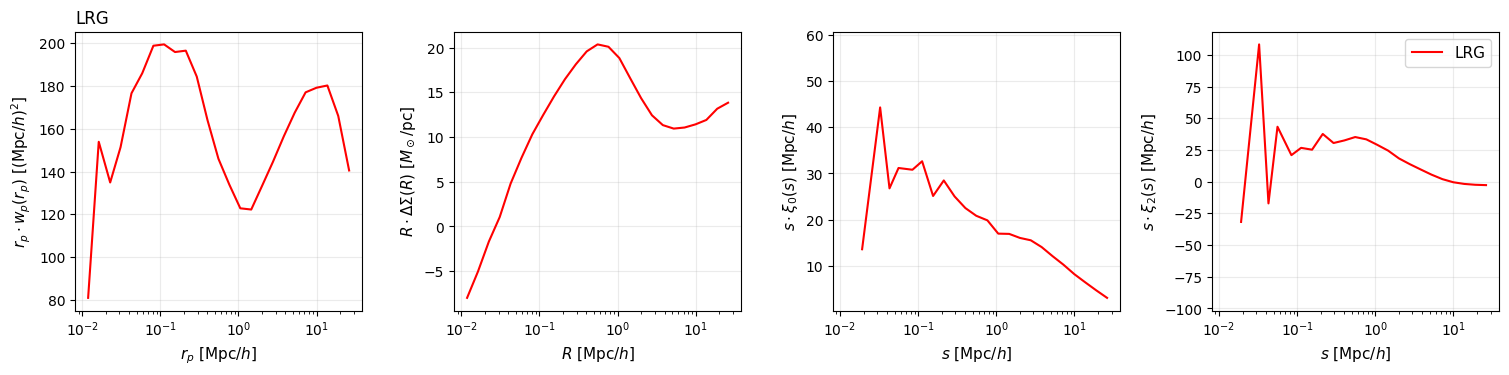

In [4]:
fig = HOD_obj.plot_stats(cat, stats=['wp', 'delta_sigma', 'xi_ells'], residuals=True, fontsize=11)


In [81]:
cat = HOD_obj.make_mock_cat(verbose=False)
ttt = HOD_obj.compute_stats(cat, stat=['wp','xi_ells'], tracers='LRG')

[002408.71]  08-04 10:45 AbacusSummitSim              INFO     Assign satellites to particles...
[002415.30]  08-04 10:45 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[002415.30]  08-04 10:45 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[002415.31]  08-04 10:45 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[002415.48]  08-04 10:45 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[002415.48]  08-04 10:45 TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 0.18 s.
[002415.49]  08-04 10:45 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[002415.49]  08-04 10:45 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[002415.49]  08-04 10:45 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[002415.71]  08-04 10:4

In [74]:
HOD_obj.part_subsamples

In [82]:
ttt = HOD_obj.compute_stats(cat, tracers='LRG')

[002532.73]  08-04 10:47 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[002532.73]  08-04 10:47 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[002532.74]  08-04 10:47 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.


[002532.86]  08-04 10:47 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[002532.86]  08-04 10:47 TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 0.13 s.
[002532.87]  08-04 10:47 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[002532.87]  08-04 10:47 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[002532.87]  08-04 10:47 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[002533.00]  08-04 10:47 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[002533.00]  08-04 10:47 TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 0.13 s.
[002533.02]  08-04 10:47 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[002533.02]  08-04 10:47 TwoPointCorrelationFunction  INFO     Running cross-cor

/home/antoine/Bureau/Transfert/postdoc/HOD/HODDIES/HODDIES/estimators/clustering_statistics.py:135: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  Sigma_mean = np.array([2.0 / R**2 * quad(integrand, 0, R, limit=200)[0] for R in rp])


[003276.18]  08-04 10:59 HOD                          INFO     Compute wp for LRG...
[003276.18]  08-04 10:59 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[003276.18]  08-04 10:59 TwoPointCorrelationFunction  INFO     Running auto-correlation.
[003276.18]  08-04 10:59 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[003276.30]  08-04 10:59 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[003276.30]  08-04 10:59 TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 0.12 s.
[003276.30]  08-04 10:59 HOD                          INFO     Done in 0.122 s
[003276.31]  08-04 10:59 HOD                          INFO     Compute xi(s,mu) using l=[0, 2] for LRG...
[003276.31]  08-04 10:59 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[003276.31]  08-04 10:59 TwoPointCorr

/tmp/ipykernel_20841/824299375.py:39: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


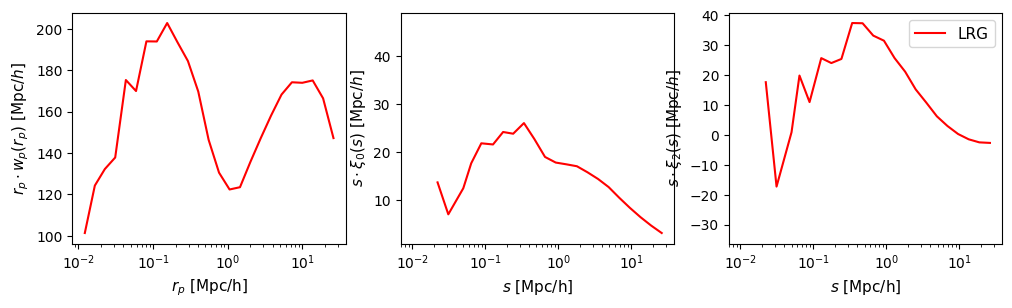

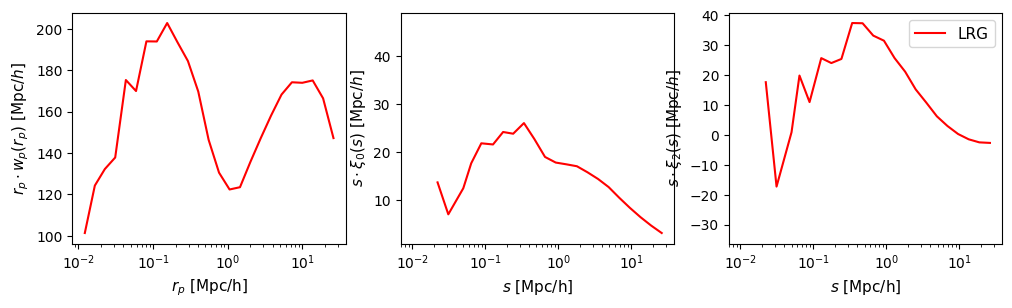

In [88]:
def plot_wp_xi(self, cat, tracers=None, fig=None, show=True, figsize=(12, 3), fontsize=11, **kwargs):
        import matplotlib.pyplot as plt
        colors = {'ELG': 'deepskyblue', 'QSO': 'seagreen', 'LRG': 'red'}
        if isinstance(tracers, str):
            tracers = [tracers]
        elif tracers is None:
            tracers = np.unique(cat['TRACER'])
        
        if fig is None:
            fig,ax = plt.subplots(1,1+len(self.args['clustering_settings']['xi_smu']['multipole_index']), figsize=figsize)
        else:
            ax = fig.axes
        for tr in tracers:
            if 'color' not in kwargs.keys(): 
                kwargs['color'] = colors[tr] if tr in colors.keys() else None

            if 'label' in kwargs.keys(): 
                label = kwargs['label']
                kwargs.pop('label')
            else:
                label = tr

            rp, wp = self.get_wp(cat, tracers=tr)
            s, xi = self.get_xiells(cat, tracers=tr)
            

            ax[0].semilogx(rp,rp*wp, **kwargs)
            ax[1].semilogx(s,s*xi[0], **kwargs)
            ax[2].semilogx(s,s*xi[1], label=label, **kwargs)
            
            ax[0].set_xlabel('$r_p$ [Mpc/h]', fontsize=fontsize)
            ax[1].set_xlabel('$s$ [Mpc/h]', fontsize=fontsize)
            ax[2].set_xlabel('$s$ [Mpc/h]', fontsize=fontsize)
            ax[0].set_ylabel(r'$r_p \cdot w_p(r_p)$ [$\mathrm{{Mpc}}/h$]', fontsize=fontsize)
            ax[1].set_ylabel(r'$s \cdot \xi_0(s)$ [$\mathrm{{Mpc}}/h$]', fontsize=fontsize)
            ax[2].set_ylabel(r'$s \cdot \xi_2(s)$ [$\mathrm{{Mpc}}/h$]', fontsize=fontsize)
            ax[2].legend(fontsize=fontsize)
        if show: 
            fig.show()
        return fig
plot_wp_xi(HOD_obj, cat)

# Need to update the initailization of parameters

In [11]:
import os
if os.path.exists('fit_functions/test_data/test_wp_data.txt'):
    rp, data, error = np.loadtxt('fit_functions/test_data/test_wp_data.txt', unpack=True, comments='#')

else:
    wp_all = []
    for i in range(20):
        cat = HOD_obj.make_mock_cat()
        rp, wp = HOD_obj.get_wp(cat, verbose=False)
        wp_all += [wp]

    data, error = np.mean(wp_all, axis=0), np.std(wp_all, axis=0)
    header = [f'#{param} = {value}' for param, value in HOD_obj.args['LRG'].items()]
    header += ['#rp [Mpc/h] wp_mean [Mpc/h] wp_std [Mpc/h]']
    np.savetxt('test_wp_data.txt', np.column_stack([rp, data, error]), header='\n'.join(header), fmt='%1.6e')

In [105]:
cat = HOD_obj.make_mock_cat()


[016018.82]  08-04 14:31 HOD                          INFO     Create mock catalog for ['LRG', 'QSO']
[016018.86]  08-04 14:31 HOD                          INFO     Run HOD for LRG
[016019.42]  08-04 14:31 AbacusSummitSim              INFO     Assign satellites to particles...
[016019.45]  08-04 14:31 HOD                          INFO     LRG mock catalogue done in 0.59 sec
[016019.45]  08-04 14:31 HOD                          INFO     Run HOD for QSO
[016019.99]  08-04 14:31 AbacusSummitSim              INFO     Assign satellites to particles...
[016020.05]  08-04 14:31 HOD                          INFO     QSO mock catalogue done in 0.59 sec
[016020.05]  08-04 14:31 HOD                          INFO     Total time to create the mock catalog: 1.23 seconds
[016020.05]  08-04 14:31 HOD                          INFO     Total number of LRG: 87446 with 65540 central, 21906 satellite and a satellites fraction: 0.25
[016020.06]  08-04 14:31 HOD                          INFO     Total number

In [89]:
HOD_obj.args['fit_param']['fit_statistics'] = ['wp']

In [104]:
HOD_obj.args['fit_param']['priors']['QSO'] = HOD_obj.args['fit_param']['priors']['LRG'].copy() 
HOD_obj.args['QSO'] = HOD_obj.args['LRG'].copy()
HOD_obj.args['tracers'] += ['QSO']

array([7.877208e+03, 6.579554e+03, 5.590860e+03, 4.615642e+03,
       3.767643e+03, 3.037682e+03, 2.345540e+03, 1.779245e+03,
       1.322587e+03, 9.539266e+02, 6.612344e+02, 4.406126e+02,
       2.776445e+02, 1.732944e+02, 1.147344e+02, 8.307909e+01,
       6.587699e+01, 5.272017e+01, 4.162986e+01, 3.240337e+01,
       2.429768e+01, 1.788480e+01, 1.293008e+01, 8.907442e+00,
       5.648578e+00, 7.877208e+03, 6.579554e+03, 5.590860e+03,
       4.615642e+03, 3.767643e+03, 3.037682e+03, 2.345540e+03,
       1.779245e+03, 1.322587e+03, 9.539266e+02, 6.612344e+02,
       4.406126e+02, 2.776445e+02, 1.732944e+02, 1.147344e+02,
       8.307909e+01, 6.587699e+01, 5.272017e+01, 4.162986e+01,
       3.240337e+01, 2.429768e+01, 1.788480e+01, 1.293008e+01,
       8.907442e+00, 5.648578e+00])

In [57]:
data = np.hstack([np.hstack([np.hstack(ttt[stat][comb_tr][-1])for stat in HOD_obj._stats_to_fit]) for comb_tr in HOD_obj._comb_tr_list])
HOD_obj.initialize_fit(data_vec=data, err=np.hstack((error,error,error)), add_poisson_noise=False, neval_poisson_noise=10)

[000927.49]  08-04 10:20 Fit HOD                      INFO     Initializing HOD.


In [63]:
HOD_obj.run_minimizer(seed=10, mpi_comm=None, method='cmaes', save_fn='fit_result.npy', maxiter=1, popsize=10, xtol=1e-3)

[000978.89]  08-04 10:21 Fit HOD                      INFO     Priors: M_0_LRG: [12.5, 13.5], M_1_LRG: [13, 14.5], alpha_LRG: [0.5, 1.5], f_sigv_LRG: [0.5, 1.5], log_Mcent_LRG: [12.4, 13.5], sigma_M_LRG: [0.05, 1], M_0_QSO: [12.5, 13.5], M_1_QSO: [13, 14.5], alpha_QSO: [0.5, 1.5], f_sigv_QSO: [0.5, 1.5], log_Mcent_QSO: [12.4, 13.5], sigma_M_QSO: [0.05, 1]
[000978.90]  08-04 10:21 Fit HOD                      INFO     First point: M_0_LRG: 13.288720744279617, M_1_LRG: 14.067970204973046, alpha_LRG: 0.9966771988881804, f_sigv_LRG: 1.224124453595385, log_Mcent_LRG: 12.559085413934634, sigma_M_LRG: 0.12521856563624628, M_0_QSO: 12.705946783186533, M_1_QSO: 13.977608662803986, alpha_QSO: 0.8714539854176223, f_sigv_QSO: 0.9407541208773083, log_Mcent_QSO: 12.541534374623767, sigma_M_QSO: 0.7754954377745815
[000978.90]  08-04 10:21 Fit HOD                      INFO     New param: M_0_LRG: 13.280098174632151, M_1_LRG: 14.110610240182803, alpha_LRG: 1.0569505130178496, f_sigv_LRG: 1.300743506988

       fun: 43507.08170024915
   message: 'maximum number of iterations is reached'
      nfev: 10
       nit: 1
 param_fit: {'tracers': ['LRG', 'QSO'], 'cosmo': {'fiducial_cosmo': None, 'engine': 'class', 'h': None, 'Omega_m': None, 'Omega_cdm': None, 'Omega_L': None, 'Omega_b': None, 'sigma_8': None, 'n_s': None, 'w0_fdl': None, 'wa_fdl': None}, 'seed': None, 'nthreads': 32, 'use_assembly_bias': False, 'use_particles': True, 'path_to_density_mesh': None, 'clustering_settings': {'rsd': True, 'los': 'z', 'xi_rppi': {'bin_logscale': True, 'pimax': 40, 'n_rp_bins': 25, 'rp_max': 30, 'rp_min': 0.01, 'edges_rppi': (array([1.00000000e-02, 1.37747857e-02, 1.89744720e-02, 2.61369285e-02,
       3.60030589e-02, 4.95934420e-02, 6.83139034e-02, 9.41009377e-02,
       1.29622025e-01, 1.78551561e-01, 2.45950949e-01, 3.38792160e-01,
       4.66678939e-01, 6.42840237e-01, 8.85498648e-01, 1.21975541e+00,
       1.68018693e+00, 2.31442149e+00, 3.18806600e+00, 4.39149258e+00,
       6.04918691e+00, 8.3

[022936.50]  08-04 16:27 HOD                          INFO     Create mock catalog for ['LRG', 'QSO', 'ELG']
[022936.56]  08-04 16:27 HOD                          INFO     Run HOD for LRG
[022937.17]  08-04 16:27 AbacusSummitSim              INFO     Assign satellites to particles...
[022937.19]  08-04 16:27 HOD                          INFO     LRG mock catalogue done in 0.64 sec
[022937.20]  08-04 16:27 HOD                          INFO     Run HOD for QSO
[022937.81]  08-04 16:27 AbacusSummitSim              INFO     Assign satellites to particles...
[022937.84]  08-04 16:27 HOD                          INFO     QSO mock catalogue done in 0.65 sec
[022937.84]  08-04 16:27 HOD                          INFO     Run HOD for ELG
[022938.54]  08-04 16:27 AbacusSummitSim              INFO     Assign satellites to particles...
[022938.57]  08-04 16:27 HOD                          INFO     ELG mock catalogue done in 0.73 sec
[022938.58]  08-04 16:27 HOD                          INFO     Tot

/tmp/ipykernel_20841/4139563364.py:847: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


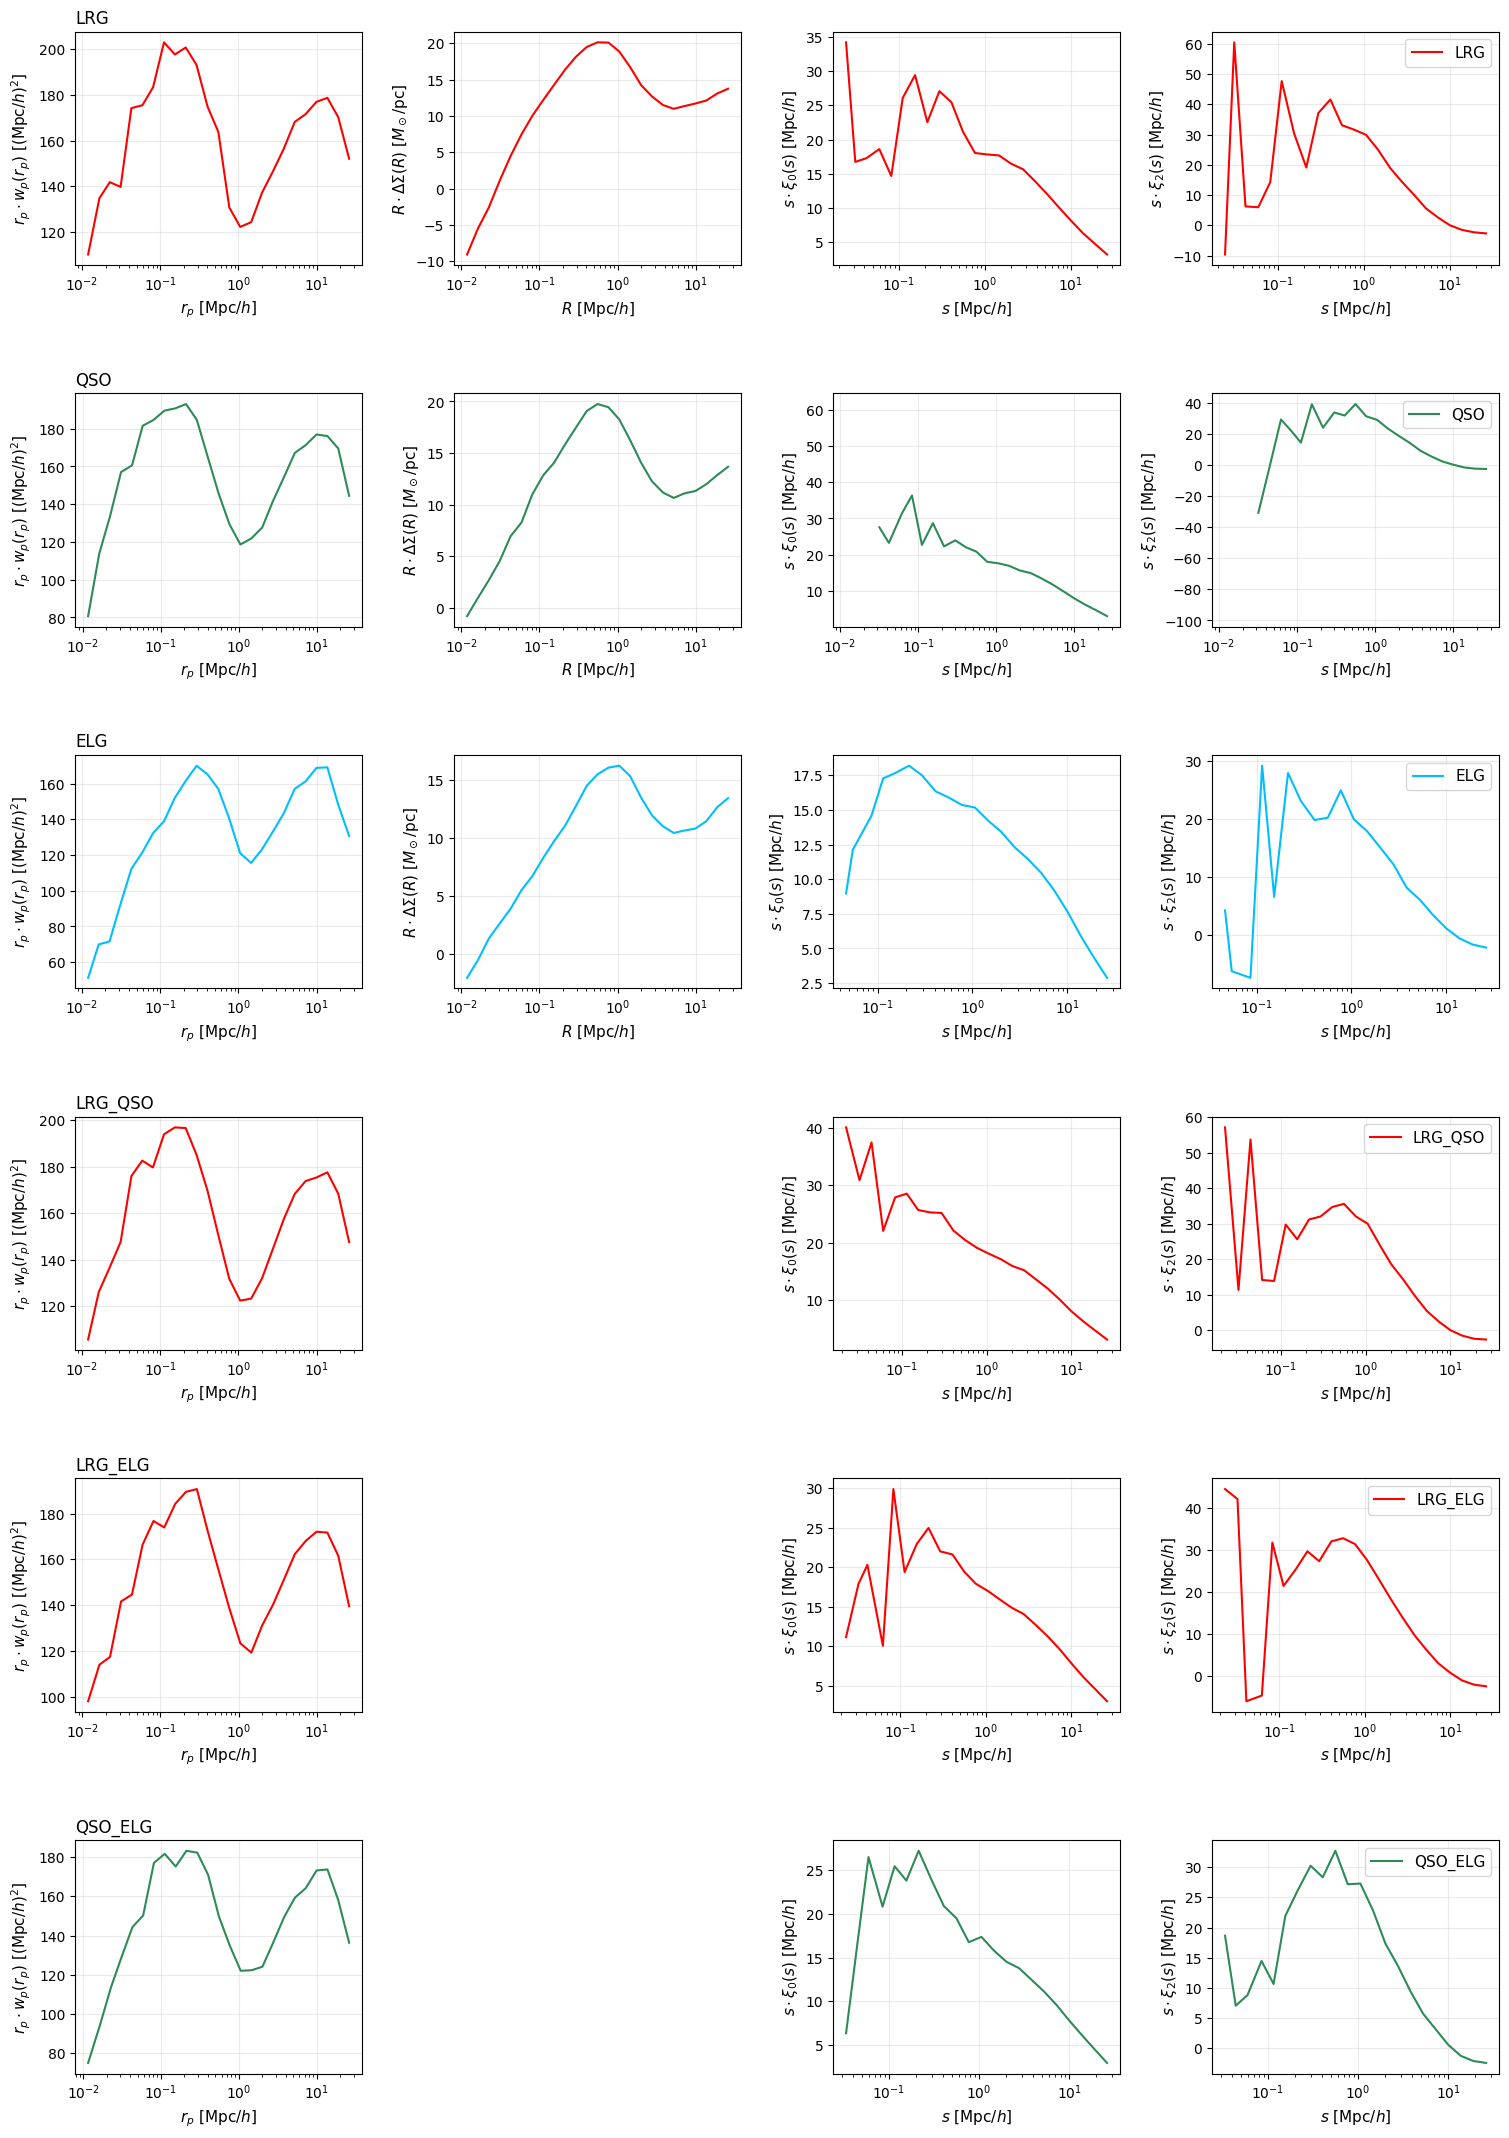

In [206]:
"""
Generic plotting of clustering statistics.

One statistic per panel. Which statistics are shown is given as input, and
new statistics are added by registering a `StatSpec` -- no change to the
plotting code itself.

If measured data (+ errors) are supplied for a statistic, the data are shown
as points with error bars and a residual sub-panel (model - data)/sigma is
added underneath that panel.
"""

import warnings
from dataclasses import dataclass, field
from typing import Callable, Optional, Sequence, Mapping

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm


# ----------------------------------------------------------------------
# Statistic registry
# ----------------------------------------------------------------------
@dataclass
class StatSpec:
    """Declarative description of one statistic.

    Parameters
    ----------
    source : str
        Key under which this quantity appears in the dict returned by
        ``obj.compute_stats(cat, stat=[...])``, i.e.
        ``tt[source][tracer]``. Several statistics may share one source
        (e.g. the multipoles all come from ``'xi_ells'``).
    xlabel, ylabel : str
        Axis labels (LaTeX allowed).
    component : int or None
        Index into ``y`` when the source holds several components.
        ``None`` means ``y`` is already the quantity to plot.
    scale : callable or None
        ``(x, y) -> y_plot``, applied before plotting. Use for the usual
        ``x * y`` presentation. ``None`` means plot ``y`` as is.
    xscale, yscale : str
        Matplotlib axis scales.
    ndim : int
        1 for curves, 2 for maps drawn with ``pcolormesh``.
    mirror : bool
        (2D only) Mirror the map into all four quadrants, i.e. reflect
        about both axes, giving the usual wedge plot of
        :math:`\\xi(r_p, \\pi)`.
    linthresh : float or None
        (2D only) If set, use a ``symlog`` x-axis with this linear
        threshold -- needed when mirroring a logarithmically binned
        coordinate through zero.
    levels : sequence or None
        (2D only) Contour levels overlaid on the map. ``None`` for no
        contours.
    shading : str
        (2D only) ``pcolormesh`` shading; ``'gouraud'`` interpolates
        across cells for an ``imshow``-like smooth map.
    prepare : callable or None
        ``entry -> (x, y)``, applied to the raw ``tt[source][tracer]``
        value before plotting. Use when the stored result is not already
        a coordinate/value pair -- e.g. CIC returns per-object neighbour
        counts that must be histogrammed first.
    residual : {'sigma', 'ratio'}
        How the residual sub-panel is computed. ``'sigma'`` plots
        ``(model - data)/sigma``; ``'ratio'`` plots ``model/data - 1``,
        which is the natural comparison for a counts distribution.
    residual_ylim : tuple or None
        Explicit y-limits for the residual panel.
    getter_kwargs : dict
        Extra keyword arguments forwarded to ``compute_stats``.
    """
    source: str
    xlabel: str = ''
    ylabel: str = ''
    component: Optional[int] = None
    scale: Optional[Callable] = None
    xscale: str = 'log'
    yscale: str = 'linear'
    ndim: int = 1
    mirror: bool = False
    linthresh: Optional[float] = None
    levels: Optional[Sequence] = None
    shading: str = 'gouraud'
    prepare: Optional[Callable] = None
    residual: str = 'sigma'
    residual_ylim: Optional[tuple] = None
    getter_kwargs: dict = field(default_factory=dict)


def _cic_hist(entry, bins=None, density=True):
    """Histogram raw counts-in-cells values into (centres, P(N)).

    ``entry`` is the array of per-object neighbour counts returned by
    ``compute_stats``; if it is already a ``(centres, values)`` pair it is
    passed through unchanged.
    """
    if isinstance(entry, (tuple, list)) and len(entry) == 2:
        return np.asarray(entry[0]), np.asarray(entry[1])
    counts = np.asarray(entry).ravel()
    counts = counts[np.isfinite(counts)]
    if bins is None:
        hi = int(np.nanmax(counts)) + 1 if counts.size else 15
        bins = np.arange(-0.5, hi + 1.5)
    hist, edges = np.histogram(counts, bins=bins)
    cens = 0.5 * (edges[:-1] + edges[1:])
    if density and hist.sum() > 0:
        hist = hist / hist.sum()
    return cens, hist


_MPC = r'[$\mathrm{Mpc}/h$]'

#: Built-in statistics. Extend with :func:`register_stat`.
STATS = {
    'wp': StatSpec(
        source='wp',
        xlabel=r'$r_p$ ' + _MPC,
        ylabel=r'$r_p \cdot w_p(r_p)$ ' + r'[$(\mathrm{Mpc}/h)^2$]',
        scale=lambda x, y: x * y),

    # Multipoles. These defaults assume get_xiells returns the orders in
    # the order [0, 2, 4]; requesting the group 'xi_ells' instead re-reads
    # the configured multipole list and overrides these with the correct
    # component indices.
    'xi0': StatSpec(
        source='xi_ells', component=0,
        xlabel=r'$s$ ' + _MPC,
        ylabel=r'$s \cdot \xi_0(s)$ ' + _MPC,
        scale=lambda x, y: x * y),

    'xi2': StatSpec(
        source='xi_ells', component=1,
        xlabel=r'$s$ ' + _MPC,
        ylabel=r'$s \cdot \xi_2(s)$ ' + _MPC,
        scale=lambda x, y: x * y),

    'xi4': StatSpec(
        source='xi_ells', component=2,
        xlabel=r'$s$ ' + _MPC,
        ylabel=r'$s \cdot \xi_4(s)$ ' + _MPC,
        scale=lambda x, y: x * y),

    'CIC': StatSpec(
        source='CIC', prepare=lambda e: _cic_hist(e),
        xlabel=r'$N_\mathrm{CIC}$',
        ylabel=r'$P(N_\mathrm{CIC})$',
        xscale='linear', yscale='log',
        residual='ratio', residual_ylim=(-0.3, 0.3)),

    'delta_sigma': StatSpec(
        source='delta_sigma',
        xlabel=r'$R$ ' + _MPC,
        ylabel=r'$R \cdot \Delta\Sigma(R)$ ' + r'[$M_\odot/\mathrm{pc}$]',
        scale=lambda x, y: x * y),

    # 2D statistics
    'xi_rppi': StatSpec(
        source='xi_rppi', ndim=2,
        xlabel=r'$r_p$ ' + _MPC, ylabel=r'$\pi$ ' + _MPC,
        mirror=True, linthresh=1.0, shading='gouraud',
        levels=(0.2, 1, 10, 50, 100)),

    'xi_smu': StatSpec(
        source='xi_smu', ndim=2,
        xlabel=r'$s$ ' + _MPC, ylabel=r'$\mu$',
        shading='gouraud'),
}


def register_stat(name, **kwargs):
    """Add (or override) a statistic in the registry.

    >>> register_stat('xi_bar', source='xi_bar',
    ...               xlabel='$s$', ylabel=r'$\\bar\\xi$',
    ...               scale=lambda x, y: x**2 * y)
    """
    STATS[name] = StatSpec(**kwargs)
    return STATS[name]


# ----------------------------------------------------------------------
# Stat groups: one requested name expanding into several panels.
# A group is a callable ``(obj) -> list of stat names``, so the expansion
# can depend on the analysis object's configuration.
# ----------------------------------------------------------------------
def _xi_ells_group(obj):
    """Expand ``'xi_ells'`` into one panel per configured multipole.

    Reads the list of multipole orders from
    ``obj.args['clustering_settings']['xi_smu']['multipole_index']``,
    e.g. ``[0, 2, 4]``. Position ``i`` in that list is component ``i``
    of the array returned by ``get_xiells`` and carries order
    ``ells[i]``, so the panels are labelled :math:`\\xi_{\\ell}`
    accordingly.
    """
    ells = None
    try:
        ells = obj.args['clustering_settings']['xi_smu']['multipole_index']
    except (AttributeError, KeyError, TypeError):
        pass
    if ells is None:
        ells = [0, 2, 4]
    names = []
    for i, ell in enumerate(ells):
        ell = int(ell)
        name = f'xi{ell}'
        # component is the POSITION in the list, not the order itself
        register_stat(name, source='xi_ells', component=i,
                      xlabel=r'$s$ ' + _MPC,
                      ylabel=rf'$s \cdot \xi_{{{ell}}}(s)$ ' + _MPC,
                      scale=lambda x, y: x * y)
        names.append(name)
    return names


def _pk_ells_group(obj):
    """Expand ``'power_spectrum'`` into one panel per multipole.

    Uses the same configured multipole list as ``'xi_ells'``. If your
    ``compute_stats`` returns a single P(k) rather than a stack of
    multipoles, register a plain statistic instead::

        register_stat('power_spectrum', source='power_spectrum',
                      xlabel=r'$k$ [$h$/Mpc]', ylabel=r'$k P(k)$',
                      scale=lambda x, y: x * y)
    """
    ells = None
    try:
        ells = obj.args['clustering_settings']['xi_smu']['multipole_index']
    except (AttributeError, KeyError, TypeError):
        pass
    if ells is None:
        ells = [0, 2, 4]
    names = []
    for i, ell in enumerate(ells):
        ell = int(ell)
        name = f'pk{ell}'
        register_stat(name, source='power_spectrum', component=i,
                      xlabel=r'$k$ [$h/\mathrm{Mpc}$]',
                      ylabel=rf'$k \cdot P_{{{ell}}}(k)$ '
                             r'[$(\mathrm{Mpc}/h)^2$]',
                      scale=lambda x, y: x * y)
        names.append(name)
    return names


#: Names that expand into several statistics.
STAT_GROUPS = {
    'xi_ells': _xi_ells_group,
    'power_spectrum': _pk_ells_group,
}


def register_group(name, resolver):
    """Register a name that expands into several statistics.

    ``resolver`` is a callable ``(obj) -> list of stat names``.
    """
    STAT_GROUPS[name] = resolver
    return resolver


def _resolve_name(name, mapping):
    """Case-insensitive lookup: return the canonical key, or None."""
    if name in mapping:
        return name
    low = name.lower()
    for k in mapping:
        if k.lower() == low:
            return k
    return None


def _expand_stats(obj, stats):
    """Resolve names case-insensitively and expand any groups."""
    out = []
    for s in stats:
        grp = _resolve_name(s, STAT_GROUPS)
        if grp is not None:
            out.extend(STAT_GROUPS[grp](obj))
            continue
        key = _resolve_name(s, STATS)
        out.append(key if key is not None else s)
    return out


# ----------------------------------------------------------------------
# helpers
# ----------------------------------------------------------------------
def _sigma(err):
    """Accept a 1D error vector or an (N, N) covariance; return sigma."""
    err = np.asarray(err)
    if err.ndim == 1:
        return err
    if err.ndim == 2 and err.shape[0] == err.shape[1]:
        return np.sqrt(np.diag(err))
    raise ValueError(f'error array of shape {err.shape} is neither (N,) nor (N, N)')


def _unpack_data(entry):
    """Normalise a user-supplied data entry to (x, y, sigma).

    Accepts a mapping with keys x/y/err (or cov), or a 2- or 3-tuple.
    """
    if entry is None:
        return None
    if isinstance(entry, Mapping):
        x, y = np.asarray(entry['x']), np.asarray(entry['y'])
        err = entry.get('err', entry.get('cov', entry.get('sigma')))
    else:
        entry = tuple(entry)
        if len(entry) == 3:
            x, y, err = entry
        elif len(entry) == 2:
            (x, y), err = entry, None
        else:
            raise ValueError('data entry must be (x, y) or (x, y, err)')
        x, y = np.asarray(x), np.asarray(y)
    return x, y, (None if err is None else _sigma(err))


def _mirror_quadrants(x, y, z):
    """Reflect a first-quadrant map about both axes.

    Parameters
    ----------
    x, y : 1D arrays
        Positive coordinate centres, e.g. ``r_p`` and ``pi``.
    z : 2D array, shape ``(len(x), len(y))``
        Values on the first quadrant.

    Returns
    -------
    x_full, y_full : 1D arrays of length ``2*len(x)``, ``2*len(y)``
    z_full : 2D array, shape ``(len(y_full), len(x_full))``
        Laid out for ``pcolormesh(x_full, y_full, z_full)``: rows follow
        ``y_full``, columns follow ``x_full``.
    """
    x, y, zt = np.asarray(x), np.asarray(y), np.asarray(z).T   # zt: (ny, nx)
    x_full = np.concatenate([-x[::-1], x])
    y_full = np.concatenate([-y[::-1], y])
    z_full = np.block([[zt[::-1, ::-1], zt[::-1, :]],
                       [zt[:, ::-1],    zt]])
    return x_full, y_full, z_full


def _unpack_result(entry, spec):
    """Turn one ``tt[source][tracer]`` entry into ``(x, y)`` or ``(x, y, z)``.

    Accepts the common shapes:
      * ``(x, y)``            -- 1D statistic
      * ``(x, y, z)``         -- 2D statistic (map)
      * a mapping with keys ``x``/``y`` (and ``z``)
      * a bare array         -- treated as ``y``, with ``x`` an index range
    """
    if isinstance(entry, Mapping):
        x = np.asarray(entry['x'])
        y = np.asarray(entry['y'])
        if spec.ndim == 2:
            return x, y, np.asarray(entry['z'])
        return x, y
    if isinstance(entry, (tuple, list)):
        if spec.ndim == 2:
            if len(entry) != 3:
                raise ValueError(
                    f"2D statistic '{spec.source}' expects (x, y, z), "
                    f'got a sequence of length {len(entry)}')
            return (np.asarray(entry[0]), np.asarray(entry[1]),
                    np.asarray(entry[2]))
        if len(entry) == 2:
            return np.asarray(entry[0]), np.asarray(entry[1])
        raise ValueError(
            f"1D statistic '{spec.source}' expects (x, y), got a sequence "
            f'of length {len(entry)}')
    arr = np.asarray(entry)                      # bare array: y only
    return np.arange(arr.shape[-1]), arr


def _fetch(obj, spec, cat, tracer_key, cache, tracers_arg):
    """Read one statistic for one tracer (or tracer pair) from compute_stats.

    Results are cached per source so ``compute_stats`` runs once per
    statistic rather than once per panel.
    """
    if spec.source not in cache:
        try:
            cache[spec.source] = obj.compute_stats(
                cat, stat=[spec.source], tracers=tracers_arg,
                **spec.getter_kwargs)
        except TypeError:       # compute_stats without a `tracers` argument
            cache[spec.source] = obj.compute_stats(
                cat, stat=[spec.source], **spec.getter_kwargs)
    tt = cache[spec.source]
    keys = [tracer_key] if isinstance(tracer_key, str) else list(tracer_key)

    # Peel the nesting one level at a time. `compute_stats` normally
    # returns tt[source][tracer], but it may return the per-tracer dict
    # directly (when a single statistic was requested) or even the bare
    # values (when there is a single tracer). Only descend while we are
    # still looking at a mapping, otherwise `k in block` would broadcast
    # over a numpy array and raise.
    block = tt
    if isinstance(block, Mapping) and spec.source in block:
        block = block[spec.source]

    if isinstance(block, Mapping):
        found = next((k for k in keys if k in block), None)
        if found is None:
            # Not every statistic is defined for every block -- e.g.
            # delta_sigma has no cross-tracer version. Signal "absent"
            # rather than failing, so the caller can skip that panel.
            return None
        entry = block[found]
    else:
        entry = block          # not nested by tracer: use it as-is

    if spec.prepare is not None:
        return spec.prepare(entry)
    out = _unpack_result(entry, spec)
    if spec.ndim == 2:
        return out
    x, y = out
    if spec.component is not None:
        y = np.asarray(y)[spec.component]
    return x, y


# ----------------------------------------------------------------------
# main entry point
# ----------------------------------------------------------------------
def plot_stats(self, cat, stats=('wp', 'xi_ells'), tracers=None,
               data=None, residuals=True, fig=None, show=True,
               figsize=None, fontsize=11, colors=None, by_tracer='rows',
               residual_band=2.0, height_ratios=(3, 1), cmap='gist_heat_r',
               norm2d=None, block_hspace=0.55, wspace=0.32,
               data_color=None, cross=True, max_cols=4, **kwargs):
    """Plot one statistic per panel, with optional data and residuals.

    Parameters
    ----------
    cat : catalogue
        Passed straight through to the getters.
    stats : sequence of str
        Statistics to plot, one panel each. Either keys of :data:`STATS`
        (see :func:`register_stat` to add your own) or group names from
        :data:`STAT_GROUPS` that expand into several panels --
        ``'xi_ells'`` expands to one panel per configured multipole,
        read from
        ``self.args['clustering_settings']['xi_smu']['multipole_index']``.
    tracers : str, sequence of str, or None
        Tracers to overplot. ``None`` uses ``np.unique(cat['TRACER'])``.
    data : dict or None
        Measured data to compare against, keyed by statistic name, and
        optionally nested by tracer::

            data = {'wp': {'x': rp, 'y': wp, 'err': sigma_wp}}
            data = {'ELG': {'wp': (rp, wp, err), 'xi0': (s, xi0, cov)}}

        ``err`` may be a 1D vector or a full covariance matrix.
        A residual sub-panel is added for every statistic that has data.
    residuals : bool
        Draw residual sub-panels where data are available.
    cross : bool
        When several tracers are given, also show the cross-correlation
        of every pair, labelled ``'LRG_QSO'`` and obtained by calling the
        getters with ``tracers=['LRG', 'QSO']``. Set ``False`` for autos
        only.
    by_tracer : {'overlay', 'rows', 'figures'}
        How to lay out several tracers.

        ``'overlay'``  all tracers drawn on the same panels;
        ``'rows'``     one row of panels per tracer in a single figure,
                       each row titled with the tracer name (default);
        ``'figures'``  one separate figure per tracer -- a list of
                       figures is returned instead of a single figure.
    residual_band : float
        Half-width of the shaded band in the residual panels, in sigma.
    max_cols : int
        Maximum number of panel columns; statistics beyond this wrap onto
        further rows within each tracer block. Default 4.

    Returns
    -------
    fig : matplotlib Figure
    """
    default_colors = {'ELG': 'deepskyblue', 'QSO': 'seagreen', 'LRG': 'red',
                      'BGS': 'goldenrod'}
    colors = {**default_colors, **(colors or {})}

    stats = [stats] if isinstance(stats, str) else list(stats)
    stats = _expand_stats(self, stats)          # 'xi_ells' -> xi0, xi2, ...
    unknown = [s for s in stats if s not in STATS]
    if unknown:
        raise ValueError(f'unknown statistic(s) {unknown}; available: '
                         f'{sorted(STATS)} or groups {sorted(STAT_GROUPS)}')

    if isinstance(tracers, str):
        tracers = [tracers]
    elif tracers is None:
        tracers = list(np.unique(cat['TRACER']))

    # --- build the list of (label, tracer_arg, data_keys, stat_keys) ---
    # autos are single tracers; crosses are pairs. Two sets of candidate
    # keys are kept, because `compute_stats` and the user-supplied `data`
    # dict may name blocks differently: compute_stats typically uses the
    # doubled form 'LRG_LRG' for autos, while data are often keyed 'LRG'.
    # Either ordering of a cross pair is accepted. Keys are built from the
    # tracer names, never by splitting the label, since tracer names may
    # themselves contain '_' (e.g. 'ELG_LOPnotqso').
    from itertools import combinations
    blocks = [(t, t, [t, f'{t}_{t}'], [f'{t}_{t}', t]) for t in tracers]
    if cross and len(tracers) > 1:
        blocks += [(f'{a}_{b}', [a, b],
                    [f'{a}_{b}', f'{b}_{a}'],
                    [f'{a}_{b}', f'{b}_{a}'])
                   for a, b in combinations(tracers, 2)]
    labels = [lbl for lbl, _, _, _ in blocks]
    all_keys = [k for _, _, ks, _ in blocks for k in ks]

    # --- normalise the data dict to data[tracer][stat] ---------------
    data = data or {}
    if data and not any(k in data for k in all_keys):
        data = {labels[0]: data}           # single-block shorthand

    # When overplotting onto an existing figure, fall back to the data
    # that were supplied when that figure was built, so residuals can be
    # computed for the new catalogue without repeating the data.
    if fig is not None:
        cached = getattr(fig, '_plot_stats_data', None)
        if cached:
            merged = {t: dict(v) for t, v in cached.items()}
            for t, v in data.items():
                merged.setdefault(t, {}).update(v)
            data = merged

    def _data_for(keys, stat):
        """First matching key wins; `keys` may be a single key or a list."""
        if isinstance(keys, str):
            keys = [keys]
        for k in keys:
            entry = data.get(k, {}).get(stat)
            if entry is not None:
                return _unpack_data(entry)
        return None

    # a residual row is needed if any tracer has data with errors for that stat
    def _needs_resid(stat):
        spec = STATS[stat]
        for _, _, ks, _ in blocks:
            d = _data_for(ks, stat)
            if d is None:
                continue
            # ratio residuals only need the data values, not their errors
            if spec.residual == 'ratio' or d[2] is not None:
                return True
        return False

    has_resid = {s: residuals and STATS[s].ndim == 1 and _needs_resid(s)
                 for s in stats}
    any_resid = any(has_resid.values())

    # --- figure / axes ------------------------------------------------
    # `by_tracer` controls how tracers are laid out:
    #   'overlay' : all tracers on the same panels
    #   'rows'    : one row of panels per tracer (default)
    #   'figures' : one separate figure per tracer
    if by_tracer not in ('overlay', 'rows', 'figures'):
        raise ValueError("by_tracer must be 'overlay', 'rows' or 'figures'")

    # 'figures' == recurse once per tracer, returning a list of figures
    if by_tracer == 'figures' and len(blocks) > 1:
        figs = []
        for lbl, tr, ks, sks in blocks:
            sub = {}
            for k in ks:
                if k in data:
                    sub[lbl] = data[k]
                    break
            figs.append(plot_stats(
                self, cat, stats=stats,
                tracers=tr if isinstance(tr, list) else [tr],
                data=sub or None,
                cross=False,
                residuals=residuals, fig=None, show=show, figsize=figsize,
                fontsize=fontsize, colors=colors, by_tracer='overlay',
                residual_band=residual_band, height_ratios=height_ratios,
                cmap=cmap, norm2d=norm2d, block_hspace=block_hspace,
                wspace=wspace, data_color=data_color, max_cols=max_cols,
                **kwargs))
        return figs

    # number of tracer-blocks stacked vertically, and the panel grid
    # inside each block (wrapped at `max_cols` columns)
    nblock = len(blocks) if by_tracer == 'rows' else 1
    ncol = max(1, min(max_cols, len(stats)))
    nsub = int(np.ceil(len(stats) / ncol))      # panel rows per block

    if figsize is None:
        panel_h = 4.4 if any_resid else 3.4
        rows_total = nsub * nblock
        figsize = (4 * ncol,
                   panel_h * rows_total
                   + (0.9 * (rows_total - 1) if rows_total > 1 else 0))

    if fig is None:
        fig = plt.figure(figsize=figsize)
        # outer grid: one cell per panel, wrapped at `ncol` columns and
        # repeated for each tracer block. `block_hspace` separates the
        # rows; within a cell the main and residual axes are glued
        # together with hspace=0.
        outer = GridSpec(nsub * nblock, ncol, figure=fig,
                         hspace=block_hspace, wspace=wspace,
                         left=0.09, right=0.98, top=0.94, bottom=0.12)
        axes_grid = []
        for b in range(nblock):
            main_ax, res_ax = [], []
            for i, s in enumerate(stats):
                r = b * nsub + i // ncol
                c = i % ncol
                if any_resid and has_resid[s]:
                    inner = outer[r, c].subgridspec(
                        2, 1, height_ratios=height_ratios, hspace=0.0)
                    a = fig.add_subplot(inner[0])
                    rr = fig.add_subplot(inner[1], sharex=a)
                    a.tick_params(labelbottom=False)
                else:
                    a = fig.add_subplot(outer[r, c])
                    rr = None
                main_ax.append(a)
                res_ax.append(rr)
            axes_grid.append((main_ax, res_ax))
        # remember the layout so the figure can be safely reused
        fig._plot_stats_axes = axes_grid
        fig._plot_stats_stats = list(stats)
        fig._plot_stats_data = {t: dict(v) for t, v in data.items()}
        fig._plot_stats_drawn = set()
    else:                                   # reuse an existing figure
        axes_grid = getattr(fig, '_plot_stats_axes', None)
        if axes_grid is None:
            # figure not built by plot_stats: fall back to positional
            # mapping, assuming main axes come first
            axes = fig.axes
            n = len(stats)
            if len(axes) < n:
                raise ValueError(
                    f'the supplied figure has {len(axes)} axes but '
                    f'{n} statistic(s) were requested')
            axes_grid = [(list(axes[:n]),
                          (list(axes[n:]) + [None] * n)[:n])]
        else:
            prev = getattr(fig, '_plot_stats_stats', None)
            if prev is not None and prev != list(stats):
                raise ValueError(
                    f'figure was built for stats {prev}, cannot overplot '
                    f'{list(stats)}; pass the same stats or fig=None')
        nblock = len(axes_grid)

    # --- draw ---------------------------------------------------------
    # compute_stats results are cached per source for this call
    _cache = {}
    for it, (blabel, tr, bkeys, skeys) in enumerate(blocks):
        # pick the axes block for this tracer / tracer pair
        blk = it if by_tracer == 'rows' else 0
        if blk >= len(axes_grid):
            raise ValueError(
                f'no axes block for {blabel!r}: the figure has '
                f'{len(axes_grid)} block(s) but {len(blocks)} were '
                f"requested with by_tracer='{by_tracer}'. Pass fig=None to "
                'build a new figure.')
        main_ax, res_ax = axes_grid[blk]
        if by_tracer == 'rows':
            main_ax[0].set_title(blabel, fontsize=fontsize + 1, loc='left')
        kw = dict(kwargs)
        # cross blocks fall back to the first tracer's colour unless the
        # combined label has its own entry in `colors`
        kw.setdefault('color', colors.get(
            blabel, colors.get(tr[0] if isinstance(tr, list) else tr)))
        label = kw.pop('label', blabel)

        for i, name in enumerate(stats):
            spec = STATS[name]
            ax, rax = main_ax[i], res_ax[i]

            # ---- 2D statistics: map, no residual panel ---------------
            if spec.ndim == 2:
                got = _fetch(self, spec, cat, skeys, _cache, tracers)
                if got is None:      # statistic undefined for this block
                    ax.set_visible(False)
                    if rax is not None:
                        rax.set_visible(False)
                    continue
                x, y, z = got

                if spec.mirror:
                    xp, yp, zp = _mirror_quadrants(x, y, z)
                else:
                    xp, yp, zp = x, y, z.T

                # NaNs / infs are common in 2D estimators (empty bins,
                # zero pair counts). The coordinate arrays must be fully
                # finite for pcolormesh, so drop any bad bins together
                # with the matching rows/columns of the map; remaining
                # bad values in the map itself are masked so they render
                # as blank cells rather than poisoning the colour scale.
                xp, yp = np.asarray(xp, float), np.asarray(yp, float)
                zp = np.asarray(zp, float)
                gx, gy = np.isfinite(xp), np.isfinite(yp)
                if not (gx.all() and gy.all()):
                    # zp is laid out (len(yp), len(xp))
                    zp = zp[np.ix_(gy, gx)]
                    xp, yp = xp[gx], yp[gy]

                finite = np.isfinite(zp)
                if not finite.all():
                    zp = np.ma.masked_invalid(zp)

                if xp.size < 2 or yp.size < 2 or not finite.any():
                    ax.text(0.5, 0.5, 'no finite data', ha='center',
                            va='center', transform=ax.transAxes,
                            fontsize=fontsize, color='0.5')
                    ax.set_xlabel(spec.xlabel, fontsize=fontsize)
                    ax.set_ylabel(spec.ylabel, fontsize=fontsize)
                    continue

                # colour scale from the finite, positive values only
                nrm = kwargs.get('norm', norm2d)
                if nrm is None:
                    with np.errstate(invalid='ignore'):
                        pos = np.asarray(zp)[finite & (np.asarray(zp) > 0)]
                    nrm = (LogNorm(vmin=pos.min(), vmax=pos.max())
                           if pos.size else None)

                with np.errstate(invalid='ignore', divide='ignore'):
                    mesh = ax.pcolormesh(xp, yp, zp, cmap=cmap, norm=nrm,
                                         shading=spec.shading)
                fig.colorbar(mesh, ax=ax)

                # contours need plain floats; skip silently if the map is
                # entirely masked or has no finite spread
                if spec.levels is not None and finite.any():
                    zc = np.where(finite, np.asarray(zp), np.nan)
                    with warnings.catch_warnings():
                        warnings.simplefilter('ignore')
                        with np.errstate(invalid='ignore', divide='ignore'):
                            try:
                                ax.contour(xp, yp, zc,
                                           levels=list(spec.levels),
                                           colors='k', linewidths=0.8,
                                           alpha=0.8)
                            except (ValueError, TypeError):
                                pass    # degenerate map: no contours

                if spec.linthresh is not None:
                    ax.set_xscale('symlog', linthresh=spec.linthresh)
                ax.set_xlabel(spec.xlabel, fontsize=fontsize)
                ax.set_ylabel(spec.ylabel, fontsize=fontsize)
                if by_tracer == 'overlay' and len(blocks) > 1:
                    ax.set_title(blabel, fontsize=fontsize)
                continue

            # ---- model ------------------------------------------------
            got = _fetch(self, spec, cat, skeys, _cache, tracers)
            if got is None:          # statistic undefined for this block
                ax.set_visible(False)
                if rax is not None:
                    rax.set_visible(False)
                continue
            x, y = got
            y_plot = spec.scale(x, y) if spec.scale else y
            # label once per block: on the last panel (overlay) or on
            # every block's last panel (rows)
            ax.plot(x, y_plot,
                    label=label if i == len(stats) - 1 else None, **kw)

            # ---- data -------------------------------------------------
            d = _data_for(bkeys, name)
            if d is not None:
                dx, dy, dsig = d
                drawn = getattr(fig, '_plot_stats_drawn', None)
                if drawn is None:
                    drawn = fig._plot_stats_drawn = set()

                # points are drawn once per (tracer, statistic); a second
                # catalogue overplotted on the same figure reuses them
                if (blabel, name) not in drawn:
                    dy_plot = spec.scale(dx, dy) if spec.scale else dy
                    dsig_plot = None
                    if dsig is not None:
                        dsig_plot = (spec.scale(dx, dsig) if spec.scale
                                     else dsig)
                    ax.errorbar(dx, dy_plot, yerr=dsig_plot, fmt='o', ms=4,
                                mfc='none', capsize=0, lw=1.2, zorder=5,
                                color=data_color or kw.get('color'),
                                label=f'{label} data')
                    drawn.add((blabel, name))

                # ---- residuals: always for the current model ---------
                if rax is not None and (dsig is not None
                                        or spec.residual == 'ratio'):
                    ymod = np.interp(dx, x, y)      # model at the data x
                    if spec.residual == 'ratio':
                        with np.errstate(divide='ignore', invalid='ignore'):
                            res = np.where(dy != 0, ymod / dy - 1.0, np.nan)
                    else:
                        res = (ymod - dy) / dsig
                    rax.plot(dx, res, lw=1.4, color=kw.get('color'))

            ax.set_xscale(spec.xscale)
            ax.set_yscale(spec.yscale)
            ax.set_ylabel(spec.ylabel, fontsize=fontsize)
            ax.grid(alpha=0.25)

            if rax is None:
                ax.set_xlabel(spec.xlabel, fontsize=fontsize)
            else:
                rax.set_xlabel(spec.xlabel, fontsize=fontsize)
                if spec.residual == 'ratio':
                    rax.set_ylabel(r'model$/$data$-1$', fontsize=fontsize)
                else:
                    rax.set_ylabel(r'$\Delta/\sigma$', fontsize=fontsize)
                    rax.axhspan(-residual_band, residual_band,
                                color='grey', alpha=0.25)
                rax.axhline(0, ls='--', color='k', lw=1)
                if spec.residual_ylim is not None:
                    rax.set_ylim(*spec.residual_ylim)
                rax.set_xscale(spec.xscale)
                rax.grid(alpha=0.25)

    # legend on the last 1D panel of each tracer block
    for blk_main, _ in axes_grid:
        for i in range(len(stats) - 1, -1, -1):
            if STATS[stats[i]].ndim != 1 or not blk_main[i].get_visible():
                continue
            h, l = blk_main[i].get_legend_handles_labels()
            if h:
                blk_main[i].legend(fontsize=fontsize)
            break

    if not hasattr(fig, '_plot_stats_axes'):
        fig.tight_layout()
    if show:
        fig.show()
    return fig
cat = HOD_obj.make_mock_cat()
# tt = HOD_obj.compute_stats(cat, stat=['wp','xi_ells'])
# HOD_obj.args['fit_param']['priors']['ELG'] = HOD_obj.args['fit_param']['priors']['LRG'].copy() 
# HOD_obj.args['ELG'] = HOD_obj.args['LRG'].copy()
# HOD_obj.args['tracers'] += ['ELG']

fig = plot_stats(HOD_obj, cat, tracers=['LRG', 'QSO', 'ELG'], stats=['wp', 'delta_sigma', 'xi_ells'], residuals=True, fontsize=11)
# cat = HOD_obj.make_mock_cat()
# fig = plot_stats(HOD_obj, cat, stats=['wp'], colors={'LRG z2': 'k', 'QSO': 'pink'}, residuals=True, fontsize=11, fig=fig)

In [172]:
tt = HOD_obj.compute_stats(cat, stat=['wp','CIC'])


[019447.21]  08-04 15:28 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[019447.21]  08-04 15:28 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[019447.21]  08-04 15:28 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[019447.38]  08-04 15:28 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[019447.39]  08-04 15:28 TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 0.18 s.
[019447.40]  08-04 15:28 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[019447.40]  08-04 15:28 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[019447.40]  08-04 15:28 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[019447.57]  08-04 15:28 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[019447.57]

In [173]:
tt['CIC']

[array([20,  3,  1, ...,  8,  5, 12], dtype=int32),
 array([ 1,  2,  5, ..., 20, 21,  5], dtype=int32)]

In [162]:
tt = HOD_obj.compute_stats(cat, stat=['wp','xi_smu'], tracers='LRG')


[018884.44]  08-04 15:19 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[018884.44]  08-04 15:19 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[018884.44]  08-04 15:19 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[018884.65]  08-04 15:19 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[018884.65]  08-04 15:19 TwoPointCorrelationFunction  INFO     Correlation function computed in elapsed time 0.22 s.
[018884.67]  08-04 15:19 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[018884.67]  08-04 15:19 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[018884.67]  08-04 15:19 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[018884.81]  08-04 15:19 TwoPointCorrelationFunction  INFO     Analytically computing two-point counts R1R2.
[018884.82]

{'LRG_LRG': [array([           nan,            nan, 2.32375820e-02, 3.18609301e-02,
         4.32698740e-02, 6.11602058e-02, 7.94178954e-02, 1.12913051e-01,
         1.56349436e-01, 2.12663152e-01, 2.93662515e-01, 4.00721037e-01,
         5.61207265e-01, 7.68653034e-01, 1.06366403e+00, 1.46424141e+00,
         2.01586392e+00, 2.77550430e+00, 3.81886397e+00, 5.26458557e+00,
         7.25261651e+00, 1.00040953e+01, 1.38055281e+01, 1.90466274e+01,
         2.62616345e+01]),
  array([-0.99, -0.97, -0.95, -0.93, -0.91, -0.89, -0.87, -0.85, -0.83,
         -0.81, -0.79, -0.77, -0.75, -0.73, -0.71, -0.69, -0.67, -0.65,
         -0.63, -0.61, -0.59, -0.57, -0.55, -0.53, -0.51, -0.49, -0.47,
         -0.45, -0.43, -0.41, -0.39, -0.37, -0.35, -0.33, -0.31, -0.29,
         -0.27, -0.25, -0.23, -0.21, -0.19, -0.17, -0.15, -0.13, -0.11,
         -0.09, -0.07, -0.05, -0.03, -0.01,  0.01,  0.03,  0.05,  0.07,
          0.09,  0.11,  0.13,  0.15,  0.17,  0.19,  0.21,  0.23,  0.25,
          0.27,  0.2

(-40.0, 40.0)

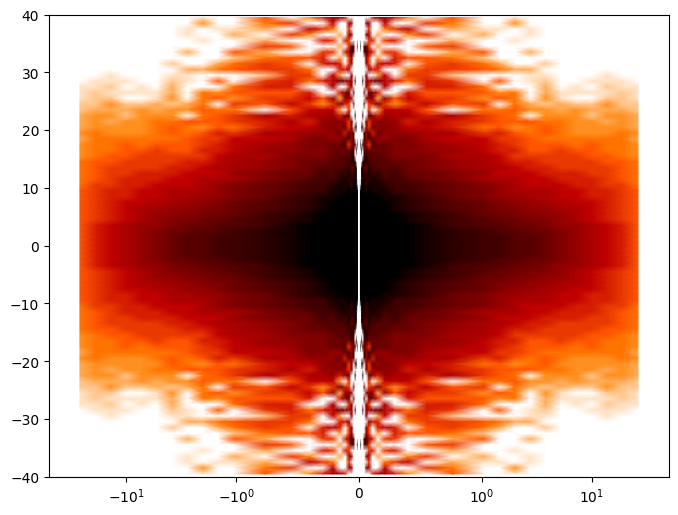

In [61]:
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

ax.axis([-50,50,-20,20])
#plt.set_aspect('equal', adjustable='box')
# plt.axes().set_aspect('equal', adjustable='box')

cmap = plt.get_cmap("gist_heat_r")
bounds = np.logspace(-2, 1.5, 20, base=10)
norm = BoundaryNorm(boundaries=bounds, ncolors=256)

levels=[0.2, 1, 10, 50, 100]
ax.pcolormesh(rp, pi, xi.T, alpha=1, cmap=cmap, norm=norm, shading='gouraud')
ax.pcolormesh(-rp, pi,xi.T, alpha=1, cmap=cmap, norm=norm, shading='gouraud')
ax.pcolormesh(rp,-pi,xi.T, alpha=1, cmap=cmap, norm=norm, shading='gouraud')
ax.pcolormesh(-rp,-pi,xi.T, alpha=1, cmap=cmap, norm=norm, shading='gouraud')
# plt.contour(rp, pi, xi.T, levels=levels, alpha=0.8, colors='k',norm=norm)
# plt.contour(-rp, pi, xi.T, levels=levels, alpha=0.8, colors='k',norm=norm)
# plt.contour(rp, -pi, xi.T, levels=levels, alpha=0.8, colors='k',norm=norm)
# plt.contour(-rp, -pi, xi.T, levels=levels, alpha=0.8, colors='k',norm=norm)

ax.set_xscale('symlog', linthresh=1)
# plt.xlim(-s.max(),s.max())
ax.set_ylim(-40,40)

# plt.xscale('log')

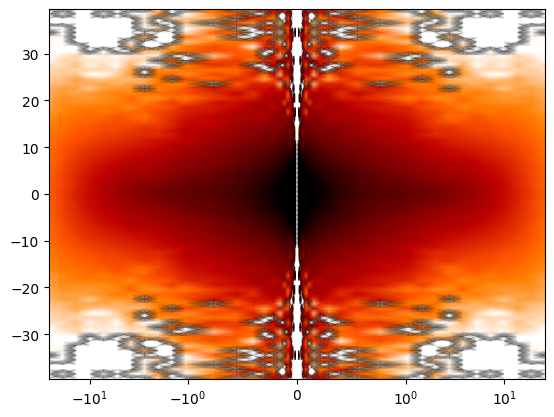

In [71]:
from matplotlib.colors import LogNorm

norm = LogNorm(vmin=0.01, vmax=100)
for sx in (1, -1):
    for sy in (1, -1):
        plt.pcolormesh(sx*rp, sy*pi, xi.T, cmap=cmap, norm=norm, shading='gouraud')
plt.xscale('symlog', linthresh=1)


In [82]:
tt = {'a':1, 'b':2}

In [83]:
for i,v in (zip(tt.keys(), tt.values())):
    tt[i] = v+1

In [84]:
tt

{'a': 2, 'b': 3}

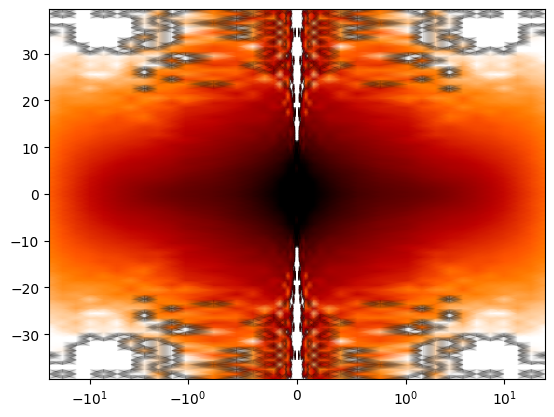

In [74]:
rp_full = np.concatenate([-rp[::-1], rp])
pi_full = np.concatenate([-pi[::-1], pi])
xi_full = np.block([[xi.T[::-1, ::-1], xi.T[::-1, :]],
                    [xi.T[:, ::-1],    xi.T]])
# (adjust the block assembly to your row/col convention)
plt.pcolormesh(rp_full, pi_full, xi_full, cmap=cmap, norm=norm, shading='gouraud')
plt.xscale('symlog', linthresh=1)


RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

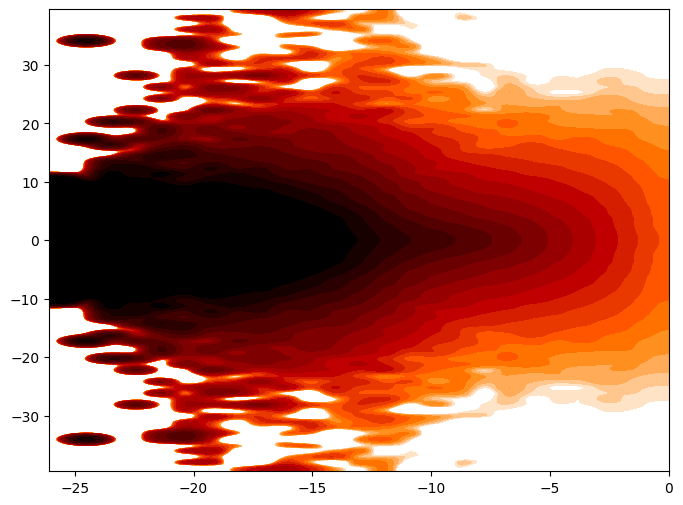

In [51]:
fig, ax = plt.subplots(figsize=(8, 6))
cmap = plt.get_cmap("gist_heat_r")
bounds = np.logspace(-2, 1.5, 20, base=10)
norm = BoundaryNorm(boundaries=bounds, ncolors=256)
im = ax.imshow(xi.T, origin='lower', extent=[0, rp.max(), -pi.max(), pi.max()], cmap=cmap, norm=norm, interpolation='gaussian', aspect='auto')
ax.imshow(xi.T, origin='lower', extent=[-rp.max(),0, -pi.max(), pi.max()], cmap=cmap, norm=norm, interpolation='gaussian', aspect='auto')

plt.colorbar(label=r'$\xi(r_p, \pi)$')

[000072.99]  07-30 14:36 HOD                          INFO     Create mock catalog for ['LRG']
[000073.01]  07-30 14:36 HOD                          INFO     Run HOD for LRG
[000073.20]  07-30 14:36 HOD                          INFO     LRG mock catalogue done in 0.20 sec
[000073.21]  07-30 14:36 HOD                          INFO     Total time to create the mock catalog: 0.22 seconds
[000073.21]  07-30 14:36 HOD                          INFO     Total number of LRG: 87159 with 65498 central, 21661 satellite and a satellites fraction: 0.25
[000073.21]  07-30 14:36 HOD                          INFO     Total number of galaxies in the catalog: 87159
[000073.22]  07-30 14:36 HOD                          INFO     Total number of centrals: 65498
[000073.22]  07-30 14:36 HOD                          INFO     Total number of satellites: 21661
[000073.23]  07-30 14:36 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[000073.23]

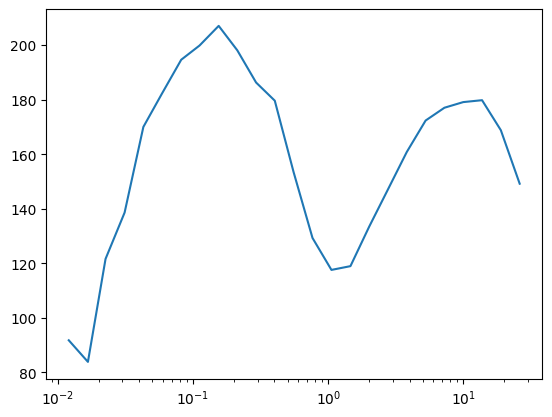

In [8]:
cat = HOD_obj.make_mock_cat()

rp,wp = HOD_obj.get_crosswp(cat, 'LRG',  verbose=False)['LRG_LRG']
plt.plot(rp, rp*wp, label='wp')
plt.xscale('log')

In [ ]:
import os
if os.path.exists('fit_functions/test_data/test_wp_data.txt'):
    rp, data, error = np.loadtxt('fit_functions/test_data/test_wp_data.txt', unpack=True, comments='#')

else:
    wp_all = []
    for i in range(20):
        cat = HOD_obj.make_mock_cat()
        rp, wp = HOD_obj.get_wp(cat, verbose=False)
        wp_all += [wp]

    data, error = np.mean(wp_all, axis=0), np.std(wp_all, axis=0)
    header = [f'#{param} = {value}' for param, value in HOD_obj.args['LRG'].items()]
    header += ['#rp [Mpc/h] wp_mean [Mpc/h] wp_std [Mpc/h]']
    np.savetxt('test_wp_data.txt', np.column_stack([rp, data, error]), header='\n'.join(header), fmt='%1.6e')

In [10]:
HOD_obj.args['fit_param']['use_desi_data'] = False
HOD_obj.args['fit_param']['fit_type'] = 'wp'
HOD_obj.initialize_fit(data_vec=data, diag_err=error, add_poisson_noise=False)

In [11]:
res = HOD_obj.run_minimizer(minimizer_options= {"maxiter":1, "popsize": 10, 'xtol':1e-6})


Priors: ('M_0_LRG', [12.5, 13.5]) ('M_1_LRG', [13, 14.5]) ('alpha_LRG', [0.5, 1.5]) ('f_sigv_LRG', [0.5, 1.5]) ('log_Mcent_LRG', [12.4, 13.5]) ('sigma_M_LRG', [0.05, 1])
First point: ('M_0_LRG', 13.445341560230958) ('M_1_LRG', 13.461653681135209) ('alpha_LRG', 0.816062848741905) ('f_sigv_LRG', 0.6345897951075086) ('log_Mcent_LRG', 12.781665760568938) ('sigma_M_LRG', 0.8717252194069068)
('M_0_LRG', 13.4273003440598) ('M_1_LRG', 13.63340290947937) ('alpha_LRG', 0.7709005362168861) ('f_sigv_LRG', 0.5807962304502885) ('log_Mcent_LRG', 12.763614707771751) ('sigma_M_LRG', 0.9002655351033636)
[000221.94]  07-30 14:38 TwoPointCorrelationFunction  INFO     Using estimator <class 'pycorr.twopoint_estimator.NaturalTwoPointEstimator'>.
[000221.94]  07-30 14:38 TwoPointCorrelationFunction  INFO     Running cross-correlation.
[000221.94]  07-30 14:38 TwoPointCorrelationFunction  INFO     Computing two-point counts D1D2.
[000222.16]  07-30 14:38 TwoPointCorrelationFunction  INFO     Analytically comp

Priors: ('M_0_QSO', [12.5, 13.5]) ('M_1_QSO', [13, 14.5]) ('alpha_QSO', [0.5, 1.5]) ('f_sigv_QSO', [0.5, 1.5]) ('log_Mcent_QSO', [12.4, 13.5]) ('sigma_M_QSO', [0.05, 1])
First point: ('M_0_QSO', 12.0) ('M_1_QSO', 13.0) ('alpha_QSO', 0.9) ('f_sigv_QSO', 1) ('log_Mcent_QSO', 12.2) ('sigma_M_QSO', 0.45)
('M_0_QSO', 12.000438974154822) ('M_1_QSO', 12.983377459608903) ('alpha_QSO', 0.98300284008051) ('f_sigv_QSO', 0.874765032071466) ('log_Mcent_QSO', 12.148352722439084) ('sigma_M_QSO', 0.4274898617622178)


/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250331-1.0.0/conda/lib/python3.10/site-packages/stochopy/optimize/cmaes/_cmaes.py:189: RuntimeWarning: invalid value encountered in scalar divide
  mueff = weights.sum() ** 2 / np.square(weights).sum()
/global/u1/a/arocher/Code/postdoc/HOD/Dev/HODDIES/HODDIES/utils.py:500: NumbaPerformanceWarning: 
The keyword argument 'parallel=True' was specified but no transformation for parallel execution was possible.

To find out why, try turning on parallel diagnostics, see https://numba.readthedocs.io/en/stable/user/parallel.html#diagnostics for help.

File "../utils.py", line 416:
@njit(fastmath=True)
def get_etavir_nfw(c): 
^

  etaVir = get_etavir_nfw(c[i])*nfw_rescale
/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250331-1.0.0/conda/lib/python3.10/site-packages/numba/parfors/parfor.py:2395: NumbaPerformanceWarning: 
prange or pndindex loop will not be executed in parallel due to there being more

chi2= 208.00856966718572
Save fit result to: results_fit.npy
Load data vector for QSO
Load rppi measurements at z0.8-1.1 for QSO...
Load smu measurements at z0.8-1.1 for QSO...
Best fit point: ('M_0_QSO', 12.000438974154822) ('M_1_QSO', 12.983377459608903) ('alpha_QSO', 0.98300284008051) ('f_sigv_QSO', 0.874765032071466) ('log_Mcent_QSO', 12.148352722439084) ('sigma_M_QSO', 0.4274898617622178)
Create mock catalog for ['QSO']
Run HOD for QSO
Set density to 0.0005 gal/Mpc/h
HOD Computed 2.4415886402130127
Start satellite assignement


/global/common/software/desi/users/adematti/perlmutter/cosmodesiconda/20250331-1.0.0/conda/lib/python3.10/site-packages/numba/parfors/parfor.py:2395: NumbaPerformanceWarning: 
prange or pndindex loop will not be executed in parallel due to there being more than one entry to or exit from the loop (e.g., an assertion).

File "../utils.py", line 488:
def compute_fast_NFW(x_h, y_h, z_h, vx_h, vy_h, vz_h, c, M, Rvir, rd_pos, rd_vel, exp_frac=0, exp_scale=1, nfw_rescale=1, vrms_h=None, f_sigv=None, v_infall=None, vel_sat='NFW', Nthread=32, seed=None):
    <source elided>
    hstart = np.rint(np.linspace(0, x_h.size, Nthread + 1))
    for tid in numba.prange(Nthread):
    ^

  warnings.warn(


Satellite assignement done 2.804579734802246
QSO mock catalogue done 2.877047300338745
380214 central galaxies, 119104 satellites, fraction of satellite 0.24 
Done overall time  QSO 6.034279823303223


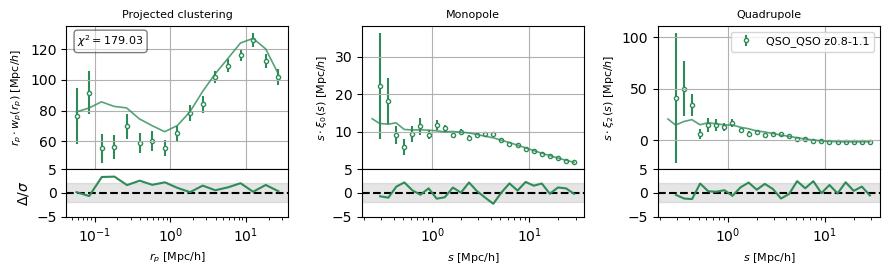

In [5]:
# Example of a run 
res = HOD_obj.run_minimizer(minimizer_options= {"maxiter":1, "popsize": 1, 'xtol':1e-6})

# Plot and save results
fig = HOD_obj.plot_bf_data(save='res_fit.png')

In [ ]:
def func_stochopy(new_params, HOD_obj, name_param, data, inv_cov2, sig=None, fix_seed=10, verbose=False, **kwargs): 

    print(*zip(name_param, new_params), flush=True)
    new_params= np.array([new_params])
    if not values_in_boundaries(new_params, HOD_obj.get_param_and_prior()[1]):
        print('param outside priors', new_params, flush=True)
        return np.inf
    new_params.dtype = [(name, dt) for name, dt in zip(name_param, ['float64']*len(name_param))]
    HOD_obj.update_new_param(new_params, name_param)

    cats = HOD_obj.make_mock_cat(fix_seed=fix_seed, verbose=verbose) 

    result = {}
    stats = []
    result['wp']= HOD_obj.get_crosswp(cats, tracers=HOD_obj.args['tracers'], verbose=verbose)
    if 'wp' in HOD_obj.args['fit_param']["fit_type"]:
        stats += ['wp']
        result['wp']= HOD_obj.get_crosswp(cats, tracers=HOD_obj.args['tracers'], verbose=verbose)
    if 'xi' in HOD_obj.args['fit_param']["fit_type"]:
        stats += ['xi']
        result['xi'] = HOD_obj.get_cross2PCF(cats, tracers=HOD_obj.args['tracers'], verbose=verbose)
    if 'delta_sigma' in HOD_obj.args['fit_param']["fit_type"]:
        stats += ['delta_sigma']
        result['delta_sigma'] = {}
        for tr in HOD_obj.args['tracers']:
            result['delta_sigma'][f'{tr}_{tr}'] = HOD_obj.get_delta_sigma(cats, tracers=tr, verbose=verbose)

    res = {}
    comb_trs = result[stats[0]].keys() 
    res = np.hstack([np.hstack([np.hstack(result[stat][comb_tr][1])for stat in stats]) for comb_tr in comb_trs])

    chi2 = compute_chi2(res, data, inv_Cov2=inv_cov2, sig=sig)
    print('chi2=', chi2, flush=True)

    return chi2

In [6]:
test = np.random.uniform(0,10,size=(30,80))
test = test.flatten()
test_d = test+ np.random.normal(0,0.5,size=test.shape)

In [7]:
tt = {}
tt['0'] = test
tt['1'] = test_d

In [38]:
cov = np.random.uniform(0,10,size=(1000, test.size))
cov = np.cov(cov,rowvar=False)
inv_cov = np.linalg.inv(cov)
inv_cov

array([[-2.69240707e+14,  2.20831921e+14,  3.36745545e+14, ...,
        -3.48326291e+13,  3.17819369e+14,  6.55883603e+14],
       [-1.32840056e+13, -5.49547061e+14, -1.50055330e+15, ...,
        -7.17405172e+13, -2.81882783e+14, -2.35861584e+15],
       [ 4.83908152e+13, -5.09390328e+14, -1.26913510e+15, ...,
        -2.01703269e+14, -2.68409303e+14, -1.93604173e+15],
       ...,
       [-9.36894305e+13,  1.27457344e+14,  4.76012197e+14, ...,
        -1.34763857e+14,  1.99116917e+14,  8.14990581e+14],
       [-8.38081115e+13, -7.29393617e+13,  1.43983517e+14, ...,
        -3.97505982e+13,  6.76717962e+13, -4.27078750e+13],
       [-1.33872491e+14,  1.85688044e+14,  7.01976616e+13, ...,
         9.64257702e+13,  1.80705201e+14,  1.30837389e+14]])

In [56]:
cov_poisson = std_poisson*std_poisson[:,None]
cov_poisson

array([[0.25, 0.25, 0.25, ..., 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, ..., 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, ..., 0.25, 0.25, 0.25],
       ...,
       [0.25, 0.25, 0.25, ..., 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, ..., 0.25, 0.25, 0.25],
       [0.25, 0.25, 0.25, ..., 0.25, 0.25, 0.25]])

In [42]:
std_poisson = np.ones(len(cov))*0.5

In [54]:
std_poisson[:,None],  std_poisson*np.eye(len(cov))

(array([[0.5],
        [0.5],
        [0.5],
        ...,
        [0.5],
        [0.5],
        [0.5]]),
 array([[0.5, 0. , 0. , ..., 0. , 0. , 0. ],
        [0. , 0.5, 0. , ..., 0. , 0. , 0. ],
        [0. , 0. , 0.5, ..., 0. , 0. , 0. ],
        ...,
        [0. , 0. , 0. , ..., 0.5, 0. , 0. ],
        [0. , 0. , 0. , ..., 0. , 0.5, 0. ],
        [0. , 0. , 0. , ..., 0. , 0. , 0.5]]))

In [19]:
def compute_chi2(model, data, inv_Cov2=None, sig=None):
    """
    Compute the chi-squared (χ²) statistic between a model and observed data.

    The function calculates χ² based on either the standard deviation of errors 
    (`sig`) or the inverse covariance matrix (`inv_Cov2`), depending on which is provided.

    Parameters:
    -----------
    model : array_like
        The predicted/model values.
    data : array_like
        The observed data values.
    inv_Cov2 : array_like, optional
        The inverse of the covariance matrix of the data. Used if `sig` is not provided.
    sig : array_like, optional
        The standard deviation (1σ errors) of the data. If provided, 
        chi-squared is computed as the sum of squared residuals normalized by the variance.

    Returns:
    --------
    chi2 : float
        The computed chi-squared value.

    Raises:
    -------
    ValueError
        If neither `sig` nor `inv_Cov2` is provided.
    """
    arr_diff = data - model
    if inv_Cov2 is not None:
        chi2 = np.matmul(arr_diff, np.matmul(inv_Cov2, arr_diff.T))
    elif sig is not None:
        chi2 = np.sum(arr_diff**2 / sig**2)
    else:
        raise ValueError('No error provided')
    return chi2

In [ ]:
HOD_obj.initialize_fit()
from HODDIES.fits_functions_old import get_corr_small_boxes
corr = get_corr_small_boxes(HOD_obj.args['fit_param'], tracers=['QSO'], zsim=0.95, fit_type='wp+xi')

Load data vector for QSO
Load rppi measurements at z0.8-1.1 for QSO...
Load smu measurements at z0.8-1.1 for QSO...
Load correlation matrix for QSO at z0.95 ...
Apply vsmear for QSO at z0.8-1.1
Load correlation matrix for QSO at z0.95 ...


In [10]:
cov = HOD_obj.sig*HOD_obj.sig[: ,None]*corr

In [13]:
cov[17:]

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.08819865e+03,  3.88324319e+02,  2.45634298e+02, ...,
         9.08289208e-03,  1.35943803e-02,  4.75962628e-03],
       [ 2.91864823e+01,  2.36166457e+02,  1.20251382e+02, ...,
        -6.18611532e-03, -7.90016157e-04,  1.13844243e-03],
       ...,
       [ 1.12445633e-01,  1.24412193e-02,  2.15421259e-03, ...,
         1.12111592e-04,  6.30985220e-05,  4.00005042e-05],
       [ 8.56500766e-02,  1.85566567e-02,  2.36218854e-02, ...,
         6.30985220e-05,  6.90617382e-05,  4.13471400e-05],
       [ 2.17797516e-03,  1.83617252e-02,  1.34560705e-03, ...,
         4.00005042e-05,  4.13471400e-05,  4.25405556e-05]])

In [10]:
import numpy as np 
mask = ~np.isnan(cov)

In [11]:
cov

array([[1.00122670e+05, 1.02050027e+03, 1.46506870e+03, ...,
        1.12445633e-01, 8.56500766e-02, 2.17797516e-03],
       [1.02050027e+03, 2.80708083e+04, 1.79964234e+02, ...,
        1.24412193e-02, 1.85566567e-02, 1.83617252e-02],
       [1.46506870e+03, 1.79964234e+02, 5.61667549e+03, ...,
        2.15421259e-03, 2.36218854e-02, 1.34560705e-03],
       ...,
       [1.12445633e-01, 1.24412193e-02, 2.15421259e-03, ...,
        1.12111592e-04, 6.30985220e-05, 4.00005042e-05],
       [8.56500766e-02, 1.85566567e-02, 2.36218854e-02, ...,
        6.30985220e-05, 6.90617382e-05, 4.13471400e-05],
       [2.17797516e-03, 1.83617252e-02, 1.34560705e-03, ...,
        4.00005042e-05, 4.13471400e-05, 4.25405556e-05]])

In [107]:
if np.isnan(HOD_obj.sig).any():
    size = HOD_obj.sig.size - np.isnan(HOD_obj.sig).sum()
    cov = cov[~np.isnan(cov)].reshape(size,size)

In [24]:
inv_cov2

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [11]:
import numpy as np 
hartlap_fac = (len(cov)+1)/(HOD_obj.args['fit_param']['nb_mocks']-1)
inv_cov2 = np.linalg.inv(cov/(1-hartlap_fac))

LinAlgError: Singular matrix

In [7]:
cov2 = np.nan_to_num(cov, nan=1)
for i, mm in enumerate(~mask):
    inv_cov2[i, mm] = 0

NameError: name 'cov' is not defined

In [50]:
inv_cov2 = np.linalg.inv(cov2/(1-hartlap_fac))
inv_cov2

array([[ 1.02812043e-05,  4.74444952e-07, -5.58318921e-07, ...,
        -1.90981428e-02, -2.53466133e-02,  7.68272368e-03],
       [ 4.65411651e-07,  3.74746735e-05,  4.11365281e-06, ...,
        -1.18502214e-02,  1.15034488e-02,  3.25058082e-02],
       [-5.86867683e-07,  4.13723471e-06,  1.91145462e-04, ...,
         6.35672523e-02, -1.51210548e-01,  1.82360485e-01],
       ...,
       [-2.11781962e-02, -6.63742059e-03,  7.45739236e-02, ...,
         2.75721102e+04, -1.35623050e+04, -3.01252541e+03],
       [-1.87621907e-02,  6.77014930e-04, -1.69410211e-01, ...,
        -1.23272997e+04,  4.60995204e+04, -4.05378220e+04],
       [ 2.56403532e-02, -3.72794691e-03,  1.12116124e-01, ...,
        -1.15644582e+03, -3.57795265e+04,  3.93830053e+04]])

In [67]:
for i, mm in enumerate(~mask):
    inv_cov2[i, mm] = 0

In [8]:
inv_cov2[17:,17:]

NameError: name 'inv_cov2' is not defined

In [63]:
inv_cov2

array([[ 1.02812043e-05,  4.74444952e-07, -5.58318921e-07, ...,
        -1.90981428e-02, -2.53466133e-02,  7.68272368e-03],
       [ 4.65411651e-07,  3.74746735e-05,  4.11365281e-06, ...,
        -1.18502214e-02,  1.15034488e-02,  3.25058082e-02],
       [-5.86867683e-07,  4.13723471e-06,  1.91145462e-04, ...,
         6.35672523e-02, -1.51210548e-01,  1.82360485e-01],
       ...,
       [-2.11781962e-02, -6.63742059e-03,  7.45739236e-02, ...,
         2.75721102e+04, -1.35623050e+04, -3.01252541e+03],
       [-1.87621907e-02,  6.77014930e-04, -1.69410211e-01, ...,
        -1.23272997e+04,  4.60995204e+04, -4.05378220e+04],
       [ 2.56403532e-02, -3.72794691e-03,  1.12116124e-01, ...,
        -1.15644582e+03, -3.57795265e+04,  3.93830053e+04]])

In [ ]:
from HODDIES.fits_functions_old import compute_chi2
compute_chi2(np.nan_to_num(HOD_obj.data) + 1, np.nan_to_num(HOD_obj.data), inv_cov2)

4.033796280537061

In [ ]:
from HODDIES.fits_functions_old import load_desi_data

data = load_desi_data(HOD_obj.args['fit_param'], ['QSO'])

Load data vector for QSO
Load rppi measurements at z0.8-1.1 for QSO...
Load smu measurements at z0.8-1.1 for QSO...


In [11]:
data['QSO_QSO']['xi'][0].size*2+17

69

In [ ]:
HOD_obj.initialize_fit()
from HODDIES.fits_functions_old import get_corr_small_boxes
corr = get_corr_small_boxes(HOD_obj.args['fit_param'], tracers=['QSO'], zsim=0.95, fit_type='wp+xi')

Load correlation matrix for QSO at z0.95 ...


Load data vector for LRG
Load rppi measurements at z0.4-0.6 for LRG...
Load smu measurements at z0.4-0.6 for LRG...
('M_0_LRG', 12.826891303915572) ('M_1_LRG', 13.823388450363534) ('alpha_LRG', 0.9829024375618897) ('f_sigv_LRG', 0.8817159066852827) ('log_Mcent_LRG', 12.708674466703727) ('sigma_M_LRG', 0.17301354342575181)
Create mock catalog for ['LRG']
Run HOD for LRG
Set density to 0.0007 gal/Mpc/h
HOD Computed 1.2046759128570557
Start satellite assignement
Satellite assignement done 0.10111594200134277
LRG mock catalogue done 0.2132105827331543
611838 central galaxies, 86576 satellites, fraction of satellite 0.12 
Done overall time  LRG 2.2390005588531494
['LRG_LRG']


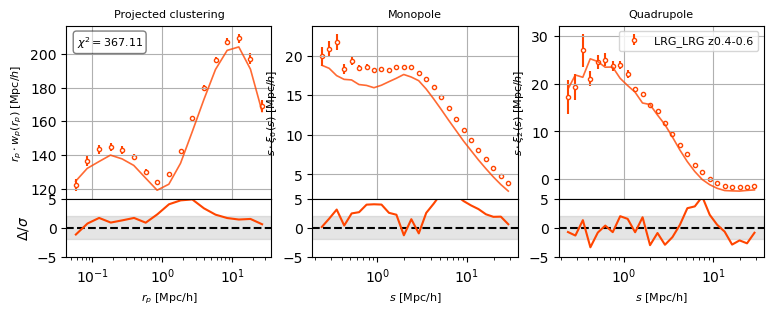

In [ ]:
#Plot best fit from a precomputed bes fit run 

fig = HOD_obj.plot_bf_data(bf_file='fit_result_LRG_SHOD_6p_AbacusSummit_highbase_c000_ph100_z0.5_wp+xi.npy', save='res_fit.png')

saved


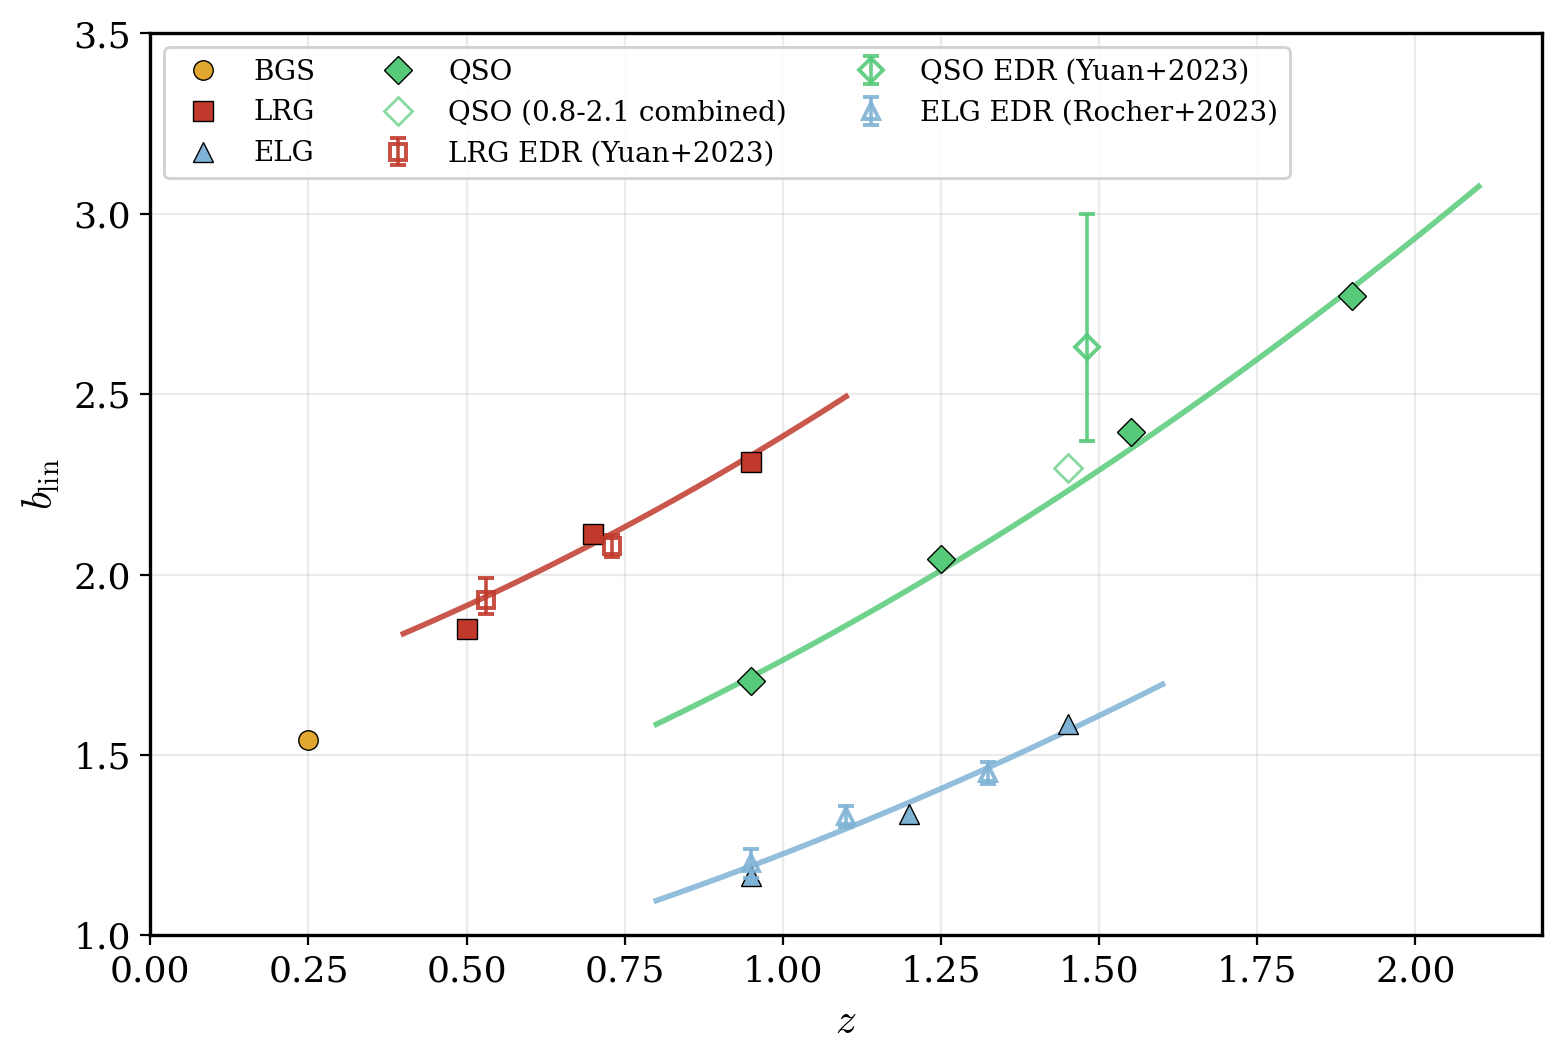

In [29]:
"""
Plot linear bias b_lin as a function of redshift for all tracers
(BGS, LRG, ELG, QSO), from the best-fit diagnostics table.

Each point sits at the centre of its redshift bin; the horizontal bar
shows the bin width. Where two model variants exist per bin, both are
plotted (they nearly overlap).
"""

import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------
# Data: (z_low, z_high, b_lin, model_variant)
# ----------------------------------------------------------------------
data = {
    'BGS': [
        (0.1, 0.4, 1.543, 'base'),
        # (0.1, 0.4, 1.555, 'baseB'),
    ],
    'LRG': [
        (0.4, 0.6, 1.850, 'base'),
        # (0.4, 0.6, 1.861, 'baseB'),
        (0.6, 0.8, 2.114, 'base'),
        # (0.6, 0.8, 2.128, 'baseB'),
        (0.8, 1.1, 2.311, 'base'),
        # (0.8, 1.1, 2.315, 'baseB'),
    ],
    'ELG': [
        (0.8, 1.1, 1.166, 'elg'),
        (1.1, 1.3, 1.336, 'elg'),
        (1.3, 1.6, 1.586, 'elg'),
    ],
    'QSO': [
        # (0.8, 2.1, 2.222, 'VB'),
        (0.8, 2.1, 2.296, 'LZ'),
        # (0.8, 1.1, 1.682, 'VB'),
        (0.8, 1.1, 1.704, 'LZ'),
        # (1.1, 1.4, 2.016, 'VB'),
        (1.1, 1.4, 2.044, 'LZ'),
        # (1.4, 1.7, 2.392, 'VB'),
        (1.4, 1.7, 2.395, 'LZ'),
        # (1.7, 2.1, 2.756, 'VB'),
        (1.7, 2.1, 2.773, 'LZ'),
    ],
}

# ----------------------------------------------------------------------
# EDR / One-Percent Survey results (Yuan et al. 2023), b_lin with
# asymmetric errors. Two model/data fits per bin: 'wp' and 'xi'.
#   (z_low, z_high, b_lin, err_plus, err_minus, fit)
# ----------------------------------------------------------------------
data_edr = {
    'LRG': [
        # (0.4, 0.6, 1.94, 0.04, 0.04, 'wp'),
        (0.4, 0.6, 1.93, 0.06, 0.04, 'xi'),
        # (0.6, 0.8, 2.11, 0.03, 0.04, 'wp'),
        (0.6, 0.8, 2.08, 0.03, 0.03, 'xi'),
    ],
    'QSO': [
        # (0.8, 2.1, 2.56, 0.22, 0.10, 'wp'),
        (0.8, 2.1, 2.63, 0.37, 0.26, 'xi'),
    ],
}

# ELG EDR points are quoted at single effective redshifts (not bins):
#   (z_eff, b_lin, err_plus, err_minus)
data_edr_elg = [
    (0.95,  1.20, 0.04, 0.04),
    (1.10,  1.33, 0.03, 0.03),
    (1.325, 1.45, 0.03, 0.03),
]

# tracer -> (colour, marker)
style = {
    'BGS': ('#E1A730', 'o'),   # gold
    'LRG': ('#C0392B', 's'),   # redder
    'ELG': ('#7FB3D5', '^'),   # pastel blue
    'QSO': ("#56CA79", 'D'),   # blue
}

# The QSO 0.8-2.1 bin is a single broad bin overlapping the finer QSO
# bins; separate it so it doesn't visually clash with the sub-bins.
QSO_BROAD = (0.8, 2.1)

plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'font.size': 13,
    'axes.linewidth': 1.2,
})

fig, ax = plt.subplots(figsize=(8, 5.5), dpi=200)

for tracer, rows in data.items():
    color, marker = style[tracer]
    # split fine bins vs the broad QSO bin
    zc, bl, xerr = [], [], []
    zc_b, bl_b, xerr_b = [], [], []
    for zlo, zhi, b, variant in rows:
        zmid = 0.5 * (zlo + zhi)
        half = 0.5 * (zhi - zlo)
        if tracer == 'QSO' and (zlo, zhi) == QSO_BROAD:
            zc_b.append(zmid); bl_b.append(b); xerr_b.append(half)
        else:
            zc.append(zmid); bl.append(b); xerr.append(half)

    ax.errorbar(zc, bl, fmt=marker, color=color,
                ms=7, lw=0, mec='k', mew=0.5,
                label=tracer, zorder=3)

    # broad QSO bin: open marker, no duplicate legend entry
    if zc_b:
        ax.errorbar(zc_b, bl_b, fmt=marker, color=color,
                    ms=7, lw=0, mfc='white', mec=color,
                    alpha=0.7, zorder=2,
                    label='QSO (0.8-2.1 combined)')

# ----------------------------------------------------------------------
# EDR results: asymmetric y-errors, slight z-offset, open markers with
# error bars. One legend entry only (first occurrence).
# ----------------------------------------------------------------------
for tracer in data_edr.keys():
    edr_labelled = False
    color, marker = style[tracer]
    for zlo, zhi, b, ep, em, fit in data_edr[tracer]:
        zmid = 0.5 * (zlo + zhi)
        # nudge the two fits apart in z for legibility
        dz = 0.03 if fit == 'xi' else -0.03
        lbl = None
        if not edr_labelled:
            lbl = f'{tracer} EDR (Yuan+2023)'
            edr_labelled = True
        ax.errorbar(zmid + dz, b, yerr=[[em], [ep]],
                    fmt=marker, color=color, ms=6, capsize=3, lw=1.3,
                    mfc='none', mec=color, mew=1.4, alpha=0.9,
                    zorder=4, label=lbl)

# ELG EDR points (single effective redshift each)
edr_labelled = False
elg_color, elg_marker = style['ELG']
for zeff, b, ep, em in data_edr_elg:
    lbl = None
    if not edr_labelled:
        lbl = 'ELG EDR (Rocher+2023)' 
        edr_labelled = True
    ax.errorbar(zeff, b, yerr=[[em], [ep]],
                fmt=elg_marker, color=elg_color, ms=6, capsize=3, lw=1.3,
                mfc='none', mec=elg_color, mew=1.4, alpha=0.9,
                zorder=4, label=lbl)

# ----------------------------------------------------------------------
# Growth factor D(z), normalised D(0)=1 (AbacusSummit c000 baseline)
# ----------------------------------------------------------------------
from scipy.integrate import quad
Om, Ol = 0.3137, 0.6863
E = lambda z: np.sqrt(Om * (1 + z)**3 + Ol)
def D_unnorm(z):
    a = 1 / (1 + z)
    integ, _ = quad(lambda ap: 1.0 / (ap * E(1/ap - 1))**3, 1e-8, a)
    return 2.5 * Om * E(z) * integ
_D0 = D_unnorm(0.0)
def Dz(z):
    return D_unnorm(z) / _D0

# ----------------------------------------------------------------------
# Bias evolution model  b(z) = alpha * (1+z)^2 + beta   per tracer
#   params[tracer] = (alpha, beta)
# ----------------------------------------------------------------------
bias_model_params = {
    # refit of b(z) = alpha*(1+z)^2 + beta to all plotted points per tracer
    'BGS': (0.60646037, 0.59540567),   # old: (0.60646037, 0.52389492)  [alpha fixed: single point]
    'LRG': (0.26840767, 1.31035620),   # old: (0.23553567, 1.3458994)
    'ELG': (0.17028987, 0.54492902),   # old: (0.15487521, 0.59464828)
    'QSO': (0.23403774, 0.82707573),   # old: (0.25207547, 0.71020952)
}

def bias_model(z, tracer):
    alpha, beta = bias_model_params[tracer]
    return alpha * (1 + z)**2 + beta

# z-coverage per tracer (min low edge .. max high edge), from the data
def tracer_zrange(tracer):
    lows, highs = [], []
    for src in (data, data_edr):
        for row in src.get(tracer, []):
            lows.append(row[0]); highs.append(row[1])
    if tracer == 'ELG':  # ELG EDR points are single z_eff, extend range
        highs.append(1.325); lows.append(0.8)
    return min(lows), max(highs)

# draw model curves for LRG, ELG, QSO (same colour as the tracer)
for tracer in ('LRG', 'ELG', 'QSO'):
    color = style[tracer][0]
    zlo, zhi = tracer_zrange(tracer)
    zg = np.linspace(zlo, zhi, 100)
    ax.plot(zg, [bias_model(z, tracer) for z in zg], '-', color=color,
            lw=2.0, alpha=0.85, zorder=2,)

# reference growth curve 1.5/D(z) as a light guide
zz = np.linspace(0.1, 2.1, 200)
# ax.plot(zz, [1.5 / Dz(z) for z in zz], 'k:', lw=1.4, alpha=0.6, label=r'$1.5/D(z)$', zorder=1)

ax.set_xlabel(r'$z$', fontsize=15)
ax.set_ylabel(r'$b_{\rm lin}$', fontsize=15)
ax.set_xlim(0.0, 2.2)
ax.set_ylim(1.0, 3.5)
ax.grid(True, alpha=0.25)
ax.legend(loc='upper left', frameon=True, framealpha=0.9, ncol=3, fontsize=10)
fig.tight_layout()
# fig.savefig('/mnt/user-data/outputs/blin_vs_z.png', dpi=200)
print('saved')

In [18]:
data.items()

dict_items([('BGS', [(0.1, 0.4, 1.543, 'base')]), ('LRG', [(0.4, 0.6, 1.85, 'base'), (0.6, 0.8, 2.114, 'base'), (0.8, 1.1, 2.311, 'base')]), ('ELG', [(0.8, 1.1, 1.166, 'elg'), (1.1, 1.3, 1.336, 'elg'), (1.3, 1.6, 1.586, 'elg')]), ('QSO', [(0.8, 2.1, 2.296, 'LZ'), (0.8, 1.1, 1.704, 'LZ'), (1.1, 1.4, 2.044, 'LZ'), (1.4, 1.7, 2.395, 'LZ'), (1.7, 2.1, 2.773, 'LZ')])])